In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 25.2 MB/s eta 0:00:00


In [ ]:
!pip install pandas numpy scikit-learn imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier

from collections import Counter
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
import textwrap
import warnings

warnings.filterwarnings('ignore')

# Import dataset

In [ ]:
df=pd.read_csv('/content/sample_data/CVD_cleaned.csv')

# Copy dataset

In [ ]:
df1=df.copy()

# Tranformasi data

In [ ]:
df1['BMI_Category'] = pd.cut(df1['BMI'], bins=[0, 18.5, 25, 30, np.inf], labels=['Underweight(<18.5)', 'Normal(18.5–24.9)', 'Overweight(25–29.9)', 'Obesity(>=30)'], right=False).astype('object')

# Informasi data

jumlah data dan kolom

In [ ]:
df1.shape

(308854, 20)

informasi data

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

10 data teratas

In [ ]:
df1.head((10))

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,BMI_Category
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0,Underweight(<18.5)
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0,Overweight(25–29.9)
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0,Obesity(>=30)
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0,Overweight(25–29.9)
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0,Normal(18.5–24.9)
5,Good,Within the past year,No,No,No,No,Yes,No,Yes,Male,60-64,183.0,154.22,46.11,No,0.0,12.0,12.0,12.0,Obesity(>=30)
6,Fair,Within the past year,Yes,Yes,No,No,No,No,Yes,Male,60-64,175.0,69.85,22.74,Yes,0.0,16.0,8.0,0.0,Normal(18.5–24.9)
7,Good,Within the past year,Yes,No,No,No,No,No,Yes,Female,65-69,165.0,108.86,39.94,Yes,3.0,30.0,8.0,8.0,Obesity(>=30)
8,Fair,Within the past year,No,No,No,No,Yes,No,No,Female,65-69,163.0,72.57,27.46,Yes,0.0,12.0,12.0,4.0,Overweight(25–29.9)
9,Fair,Within the past year,No,No,No,No,No,Yes,Yes,Female,70-74,163.0,91.63,34.67,No,0.0,12.0,12.0,1.0,Obesity(>=30)


10 data terbawah

In [ ]:
df1.tail((10))

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,BMI_Category
308844,Good,Within the past year,Yes,No,No,No,No,No,No,Male,60-64,163.0,65.32,24.72,No,8.0,4.0,4.0,2.0,Normal(18.5–24.9)
308845,Good,Within the past year,Yes,No,No,No,No,No,No,Male,55-59,170.0,104.33,36.02,No,4.0,12.0,20.0,4.0,Obesity(>=30)
308846,Very Good,Within the past year,No,No,No,No,No,Yes,Yes,Male,65-69,168.0,92.99,33.09,No,1.0,12.0,8.0,1.0,Obesity(>=30)
308847,Very Good,5 or more years ago,No,No,No,No,No,No,No,Male,40-44,163.0,65.77,24.89,No,0.0,0.0,0.0,0.0,Normal(18.5–24.9)
308848,Good,Within the past 5 years,Yes,No,No,No,No,No,No,Male,55-59,168.0,58.97,20.98,No,0.0,16.0,12.0,0.0,Normal(18.5–24.9)
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168.0,81.65,29.05,No,4.0,30.0,8.0,0.0,Overweight(25–29.9)
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180.0,69.85,21.48,No,8.0,15.0,60.0,4.0,Normal(18.5–24.9)
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157.0,61.23,24.69,Yes,4.0,40.0,8.0,4.0,Normal(18.5–24.9)
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183.0,79.38,23.73,No,3.0,30.0,12.0,0.0,Normal(18.5–24.9)
308853,Excellent,Within the past year,Yes,No,No,No,No,No,No,Female,45-49,160.0,81.19,31.71,No,1.0,5.0,12.0,1.0,Obesity(>=30)


# Preprocessing data

data duplikat

In [ ]:
duplicates = df1[df1.duplicated()]
print("Total Duplicates rows observed:", duplicates.shape[0])
print("Dropping duplicates")
# Dropping duplicates
print("Shape before dropping duplicates: ", df1.shape[0])
df1.drop_duplicates(inplace=True)
df1.reset_index(drop=True, inplace=True)
print("Shape after dropping duplicates: ", df1.shape[0])
duplicates_after_drop = df1[df1.duplicated()]
print("Total Duplicates rows observed after dropping:", duplicates_after_drop.shape[0])

Total Duplicates rows observed: 80
Dropping duplicates
Shape before dropping duplicates:  308854
Shape after dropping duplicates:  308774
Total Duplicates rows observed after dropping: 0


missing values

In [ ]:
total = df1.isnull().sum().sort_values(ascending=False)
percent = (df1.isnull().sum() / df1.isnull().count()).sort_values(ascending=False)
missing_df1 = pd.concat([total, percent*100], axis=1, keys=["Total", "Percent(%)"])
missing_df1

,Total,Percent(%)
General_Health,0,0.0
Checkup,0,0.0
Exercise,0,0.0
Heart_Disease,0,0.0
Skin_Cancer,0,0.0
Other_Cancer,0,0.0
Depression,0,0.0
Diabetes,0,0.0
Arthritis,0,0.0
Sex,0,0.0


# Exploratory data analys

kategori variabel data

In [ ]:
# Numerical variables:
num_cols = ['Height_(cm)', 'Weight_(kg)',  'Alcohol_Consumption','BMI','Fruit_Consumption', 'Green_Vegetables_Consumption','FriedPotato_Consumption']

# Categorical variables:
cat_cols = [ 'Exercise', 'Heart_Disease', 'Skin_Cancer','Other_Cancer', 'Depression',  'Arthritis', 'Sex', 'Smoking_History']

# Ordinal variables
ord_cols = ['General_Health', 'Checkup','Diabetes','Age_Category', 'BMI_Category']

unique values numerik

In [ ]:
print(f"[Unique Values in {len(num_cols)} Numerical Variables]\n")
for num_col in num_cols:
    unique_values = df1[num_col].unique()
    min_value = unique_values.min()
    max_value = unique_values.max()
    print(f"* {num_col} : {len(unique_values)} Unique Values, ranging from {min_value} to {max_value}")

[Unique Values in 7 Numerical Variables]

* Height_(cm) : 99 Unique Values, ranging from 91.0 to 241.0
* Weight_(kg) : 525 Unique Values, ranging from 24.95 to 293.02
* Alcohol_Consumption : 31 Unique Values, ranging from 0.0 to 30.0
* BMI : 3654 Unique Values, ranging from 12.02 to 99.33
* Fruit_Consumption : 77 Unique Values, ranging from 0.0 to 120.0
* Green_Vegetables_Consumption : 75 Unique Values, ranging from 0.0 to 128.0
* FriedPotato_Consumption : 69 Unique Values, ranging from 0.0 to 128.0


unique values kolom category

In [ ]:
print(f"[Unique Values in {len(cat_cols)} Categorical Variables]\n")

for cat_col in cat_cols:
    print("* {} : {} Unique Values =>".format(cat_col, df1[cat_col].nunique()), df1[cat_col].unique())


[Unique Values in 8 Categorical Variables]

* Exercise : 2 Unique Values => ['No' 'Yes']
* Heart_Disease : 2 Unique Values => ['No' 'Yes']
* Skin_Cancer : 2 Unique Values => ['No' 'Yes']
* Other_Cancer : 2 Unique Values => ['No' 'Yes']
* Depression : 2 Unique Values => ['No' 'Yes']
* Arthritis : 2 Unique Values => ['Yes' 'No']
* Sex : 2 Unique Values => ['Female' 'Male']
* Smoking_History : 2 Unique Values => ['Yes' 'No']


unique values kolom ordinal

In [ ]:
print(f"[Unique Values in {len(ord_cols)} Ordinal Variables]\n")

for ord_col in ord_cols:
    print("* {} : {} Unique Values =>".format(ord_col, df1[ord_col].nunique()), df1[ord_col].unique())

[Unique Values in 5 Ordinal Variables]

* General_Health : 5 Unique Values => ['Poor' 'Very Good' 'Good' 'Fair' 'Excellent']
* Checkup : 5 Unique Values => ['Within the past 2 years' 'Within the past year' '5 or more years ago'
 'Within the past 5 years' 'Never']
* Diabetes : 4 Unique Values => ['No' 'Yes' 'No, pre-diabetes or borderline diabetes'
 'Yes, but female told only during pregnancy']
* Age_Category : 13 Unique Values => ['70-74' '60-64' '75-79' '80+' '65-69' '50-54' '45-49' '18-24' '30-34'
 '55-59' '35-39' '40-44' '25-29']
* BMI_Category : 4 Unique Values => ['Underweight(<18.5)' 'Overweight(25–29.9)' 'Obesity(>=30)'
 'Normal(18.5–24.9)']


univariate analys numerik col

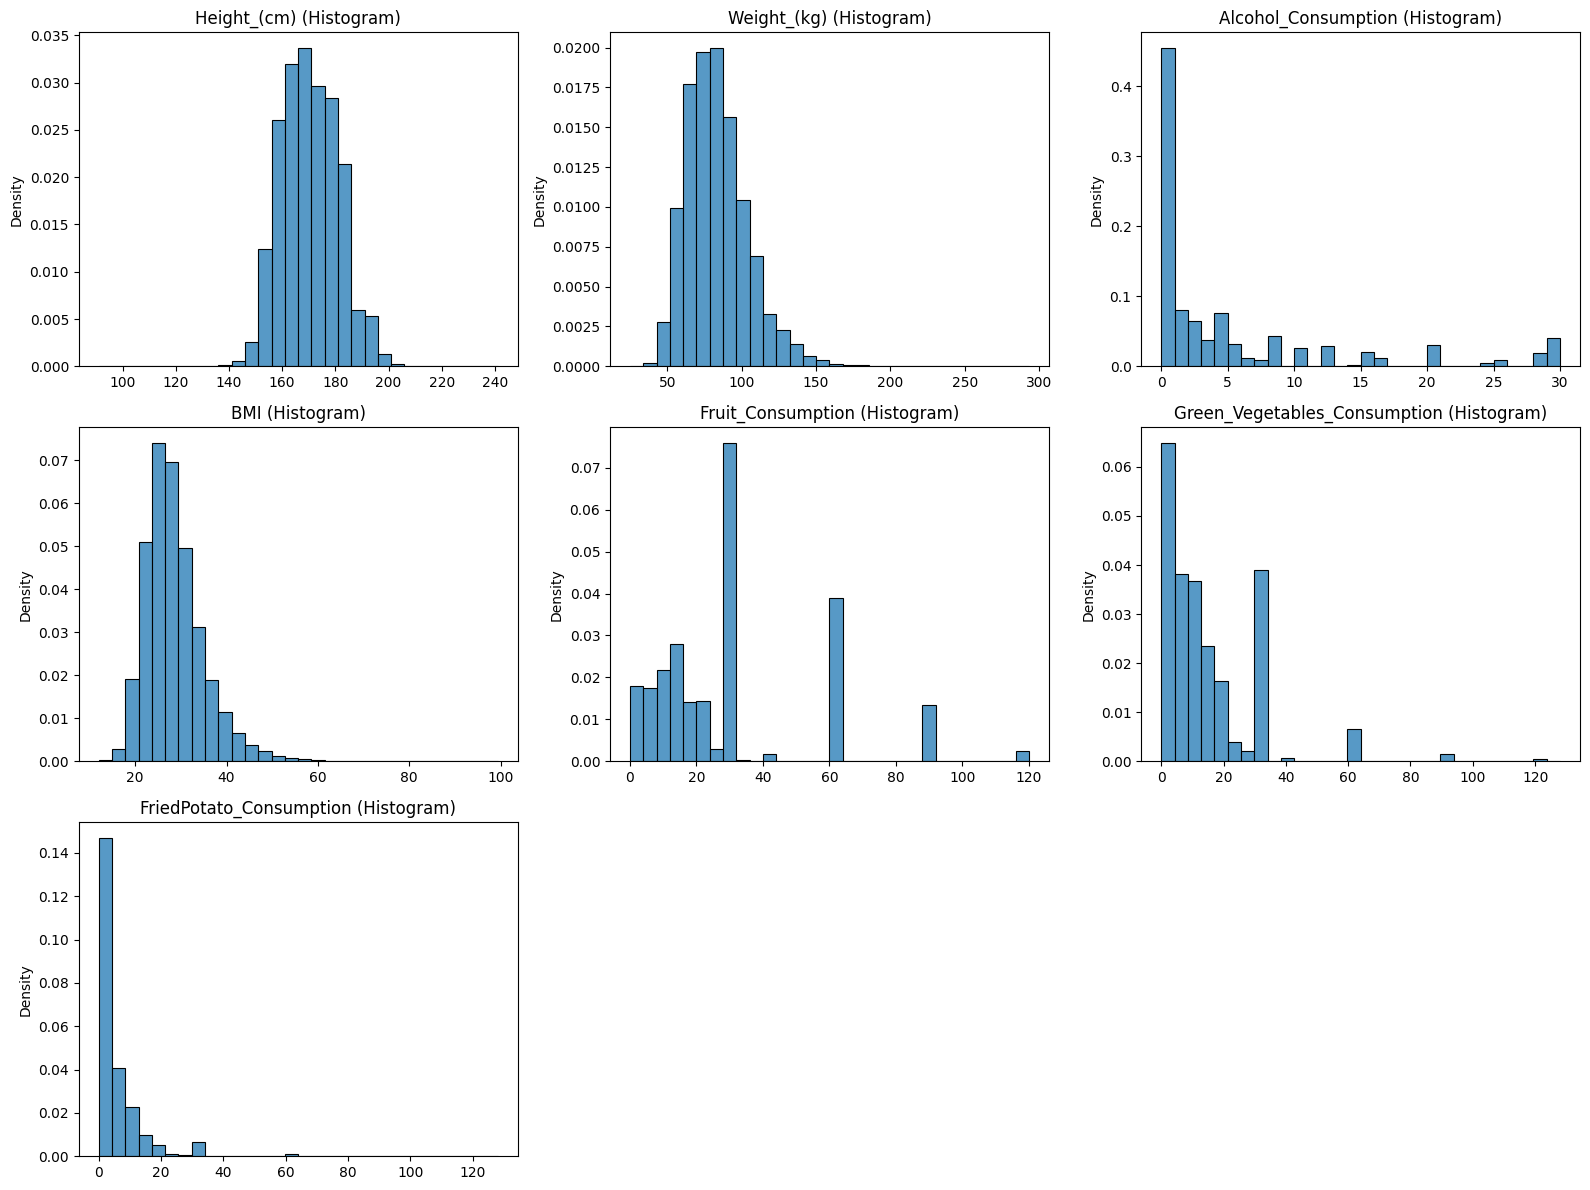

In [ ]:
n_rows, n_cols = 3, 3
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 12))
ax = ax.flatten()

for idx, col in enumerate(num_cols):

    sns.histplot(
        data=df1,
        x=col,
        bins=30,
        stat='density',
        kde=False,
        ax=ax[idx]
    )
    ax[idx].set_title(f'{col} (Histogram)', fontsize=12)
    ax[idx].set_xlabel('')
    ax[idx].set_ylabel('Density')


for j in range(len(num_cols), len(ax)):
    fig.delaxes(ax[j])

fig.tight_layout()
plt.show()

univariate analys category col

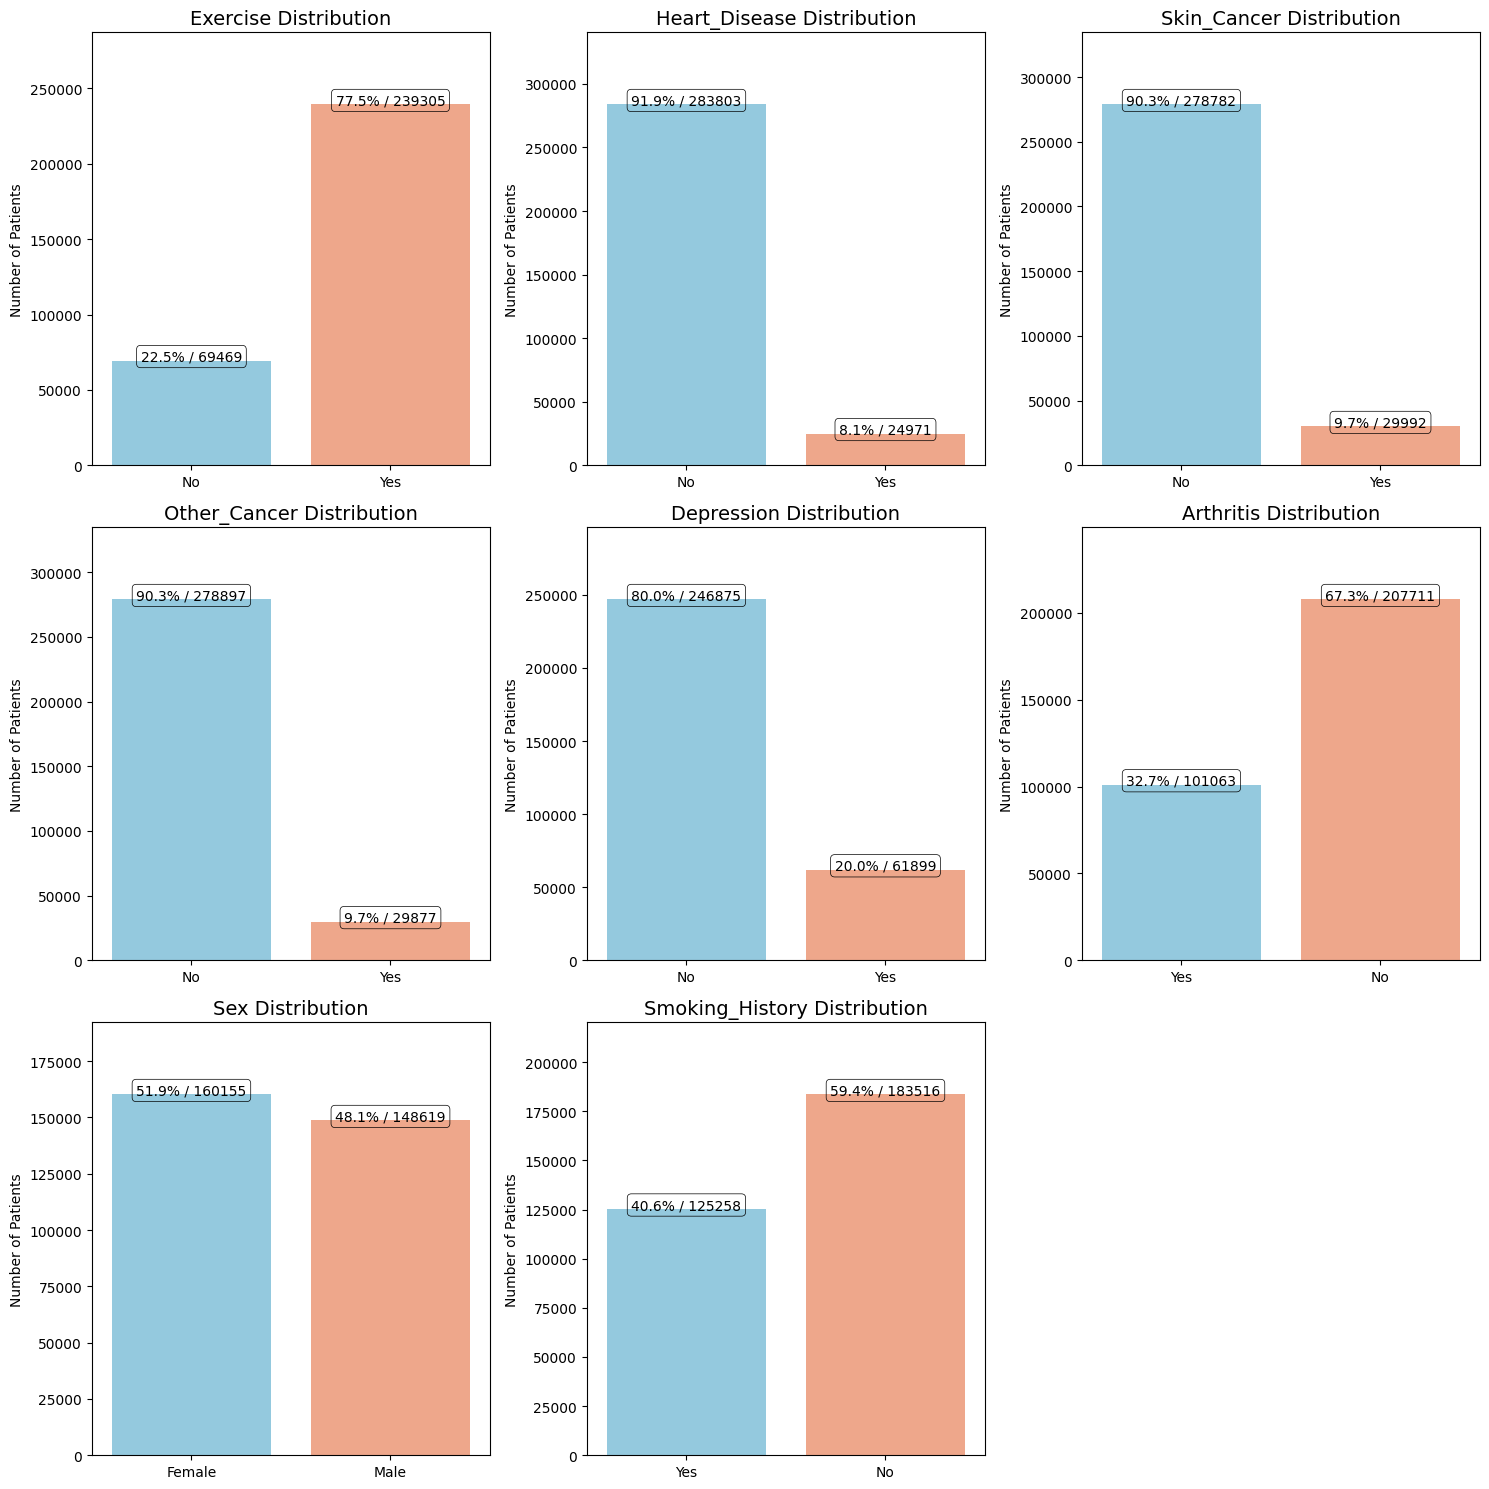

In [ ]:
n_rows, n_cols = 3, 3
fig, ax = plt.subplots(n_rows, n_cols, figsize=(15, 15))

for i, cat_col in enumerate(cat_cols[:9]):
    i_row, i_col = i // n_cols, i % n_cols
    rects = sns.countplot(x=cat_col, data=df1, ax=ax[i_row, i_col], palette=["#87CEEB", "#FFA07A"])
    for rect in rects.patches:
        height = rect.get_height()
        ax[i_row, i_col].text(rect.get_x() + rect.get_width() / 2., height + 12, "{:1.1f}% / {:d}".format(height / len(df1) * 100, height.astype(int)), ha='center', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))
    ax[i_row, i_col].set_title(f'{cat_col} Distribution', fontsize=14)
    ax[i_row, i_col].set_xlabel("")
    ax[i_row, i_col].set_ylabel("Number of Patients")
    ax[i_row, i_col].set_ylim([0, max([rect.get_height() for rect in rects.patches]) * 1.2])


if len(cat_cols) < 9:
    for i in range(len(cat_cols), n_rows * n_cols):
        i_row, i_col = i // n_cols, i % n_cols
        ax[i_row, i_col].axis('off')

fig.tight_layout()
plt.show()

oridinal col

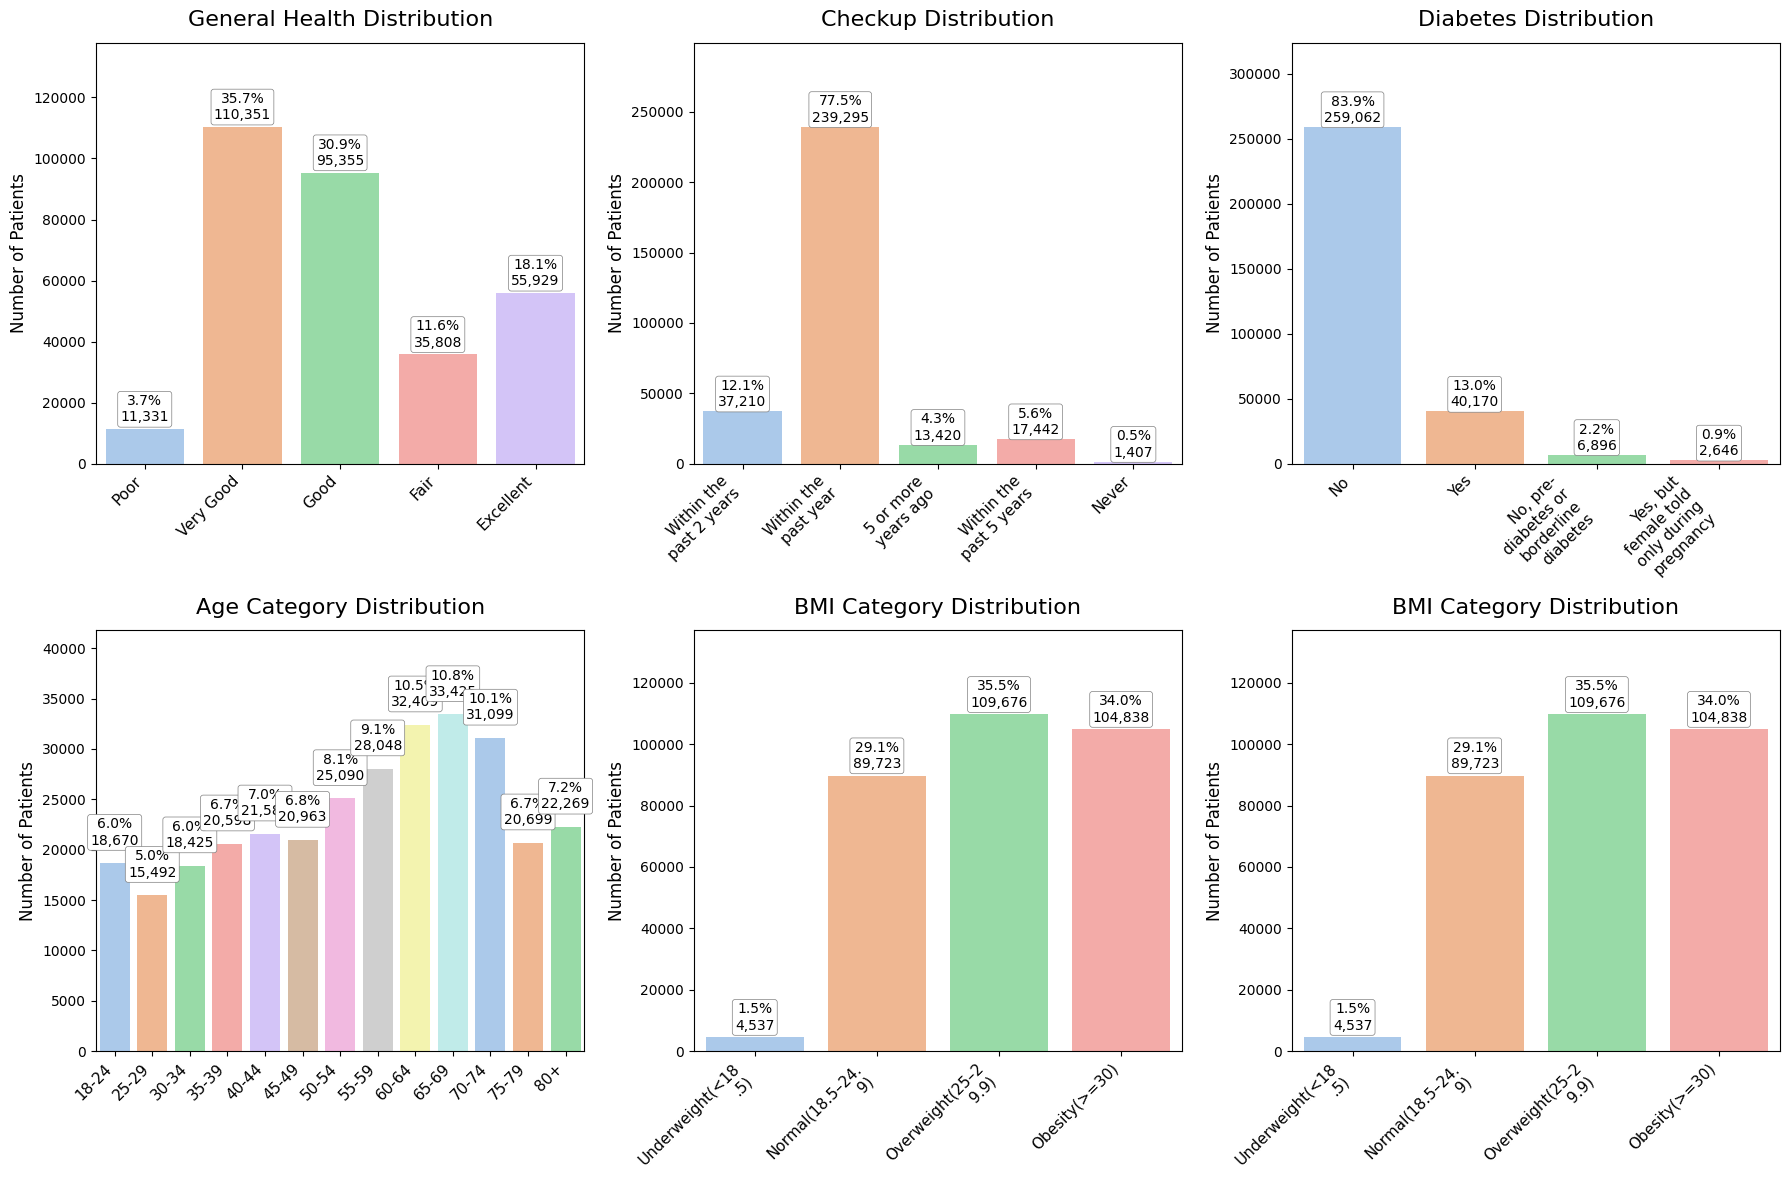

In [ ]:
labels_wrapped = {
    'General_Health': [ textwrap.fill(lbl, width=10) for lbl in ['Poor', 'Very Good', 'Good', 'Fair', 'Excellent'] ],
    'Checkup': [ textwrap.fill(lbl, width=12) for lbl in [ 'Within the past 2 years', 'Within the past year', '5 or more years ago', 'Within the past 5 years', 'Never' ] ],
    'Diabetes': [ textwrap.fill(lbl, width=12) for lbl in [ 'No', 'Yes', 'No, pre-diabetes or borderline diabetes', 'Yes, but female told only during pregnancy' ] ],
    'Age_Category': [ textwrap.fill(lbl, width=8) for lbl in ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+'] ],
    'BMI_Category': [ textwrap.fill(lbl, width=15) for lbl in ['Underweight(<18.5)', 'Normal(18.5–24.9)', 'Overweight(25–29.9)', 'Obesity(>=30)'] ]
}

orders = {
    'General_Health': ['Poor', 'Very Good', 'Good', 'Fair', 'Excellent'],
    'Checkup': [ 'Within the past 2 years', 'Within the past year', '5 or more years ago', 'Within the past 5 years', 'Never' ],
    'Diabetes': [ 'No', 'Yes', 'No, pre-diabetes or borderline diabetes', 'Yes, but female told only during pregnancy' ],
    'Age_Category': [ '18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+' ],
    'BMI_Category': ['Underweight(<18.5)', 'Normal(18.5–24.9)', 'Overweight(25–29.9)', 'Obesity(>=30)']
}

master_palette = sns.color_palette("pastel", 13)
fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # diubah menjadi 2x3
axes = axes.flatten()

for idx, col in enumerate(ord_cols + ['BMI_Category']): # tambahkan BMI_Category
    ax = axes[idx]
    n_cat = len(orders[col])
    pal = master_palette[:n_cat]
    sns.countplot( x=col, data=df1, order=orders[col], palette=pal, ax=ax )
    ax.set_xticklabels(labels_wrapped[col], rotation=45, ha="right", fontsize=11)
    ax.set_title(f"{col.replace('_', ' ')} Distribution", fontsize=16, pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("Number of Patients", fontsize=12)
    total = len(df1)
    for p in ax.patches:
        height = p.get_height()
        pct = (height / total) * 100
        xloc = p.get_x() + p.get_width() / 2
        yloc = height + total * 0.005
        ax.text( xloc, yloc, f"{pct:1.1f}%\n{int(height):,}", ha="center", va="bottom", fontsize=10, bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.2", linewidth=0.5) )
    max_h = max(p.get_height() for p in ax.patches)
    ax.set_ylim(0, max_h * 1.25)

plt.tight_layout()
plt.show()

Univariate analysis

numerik col

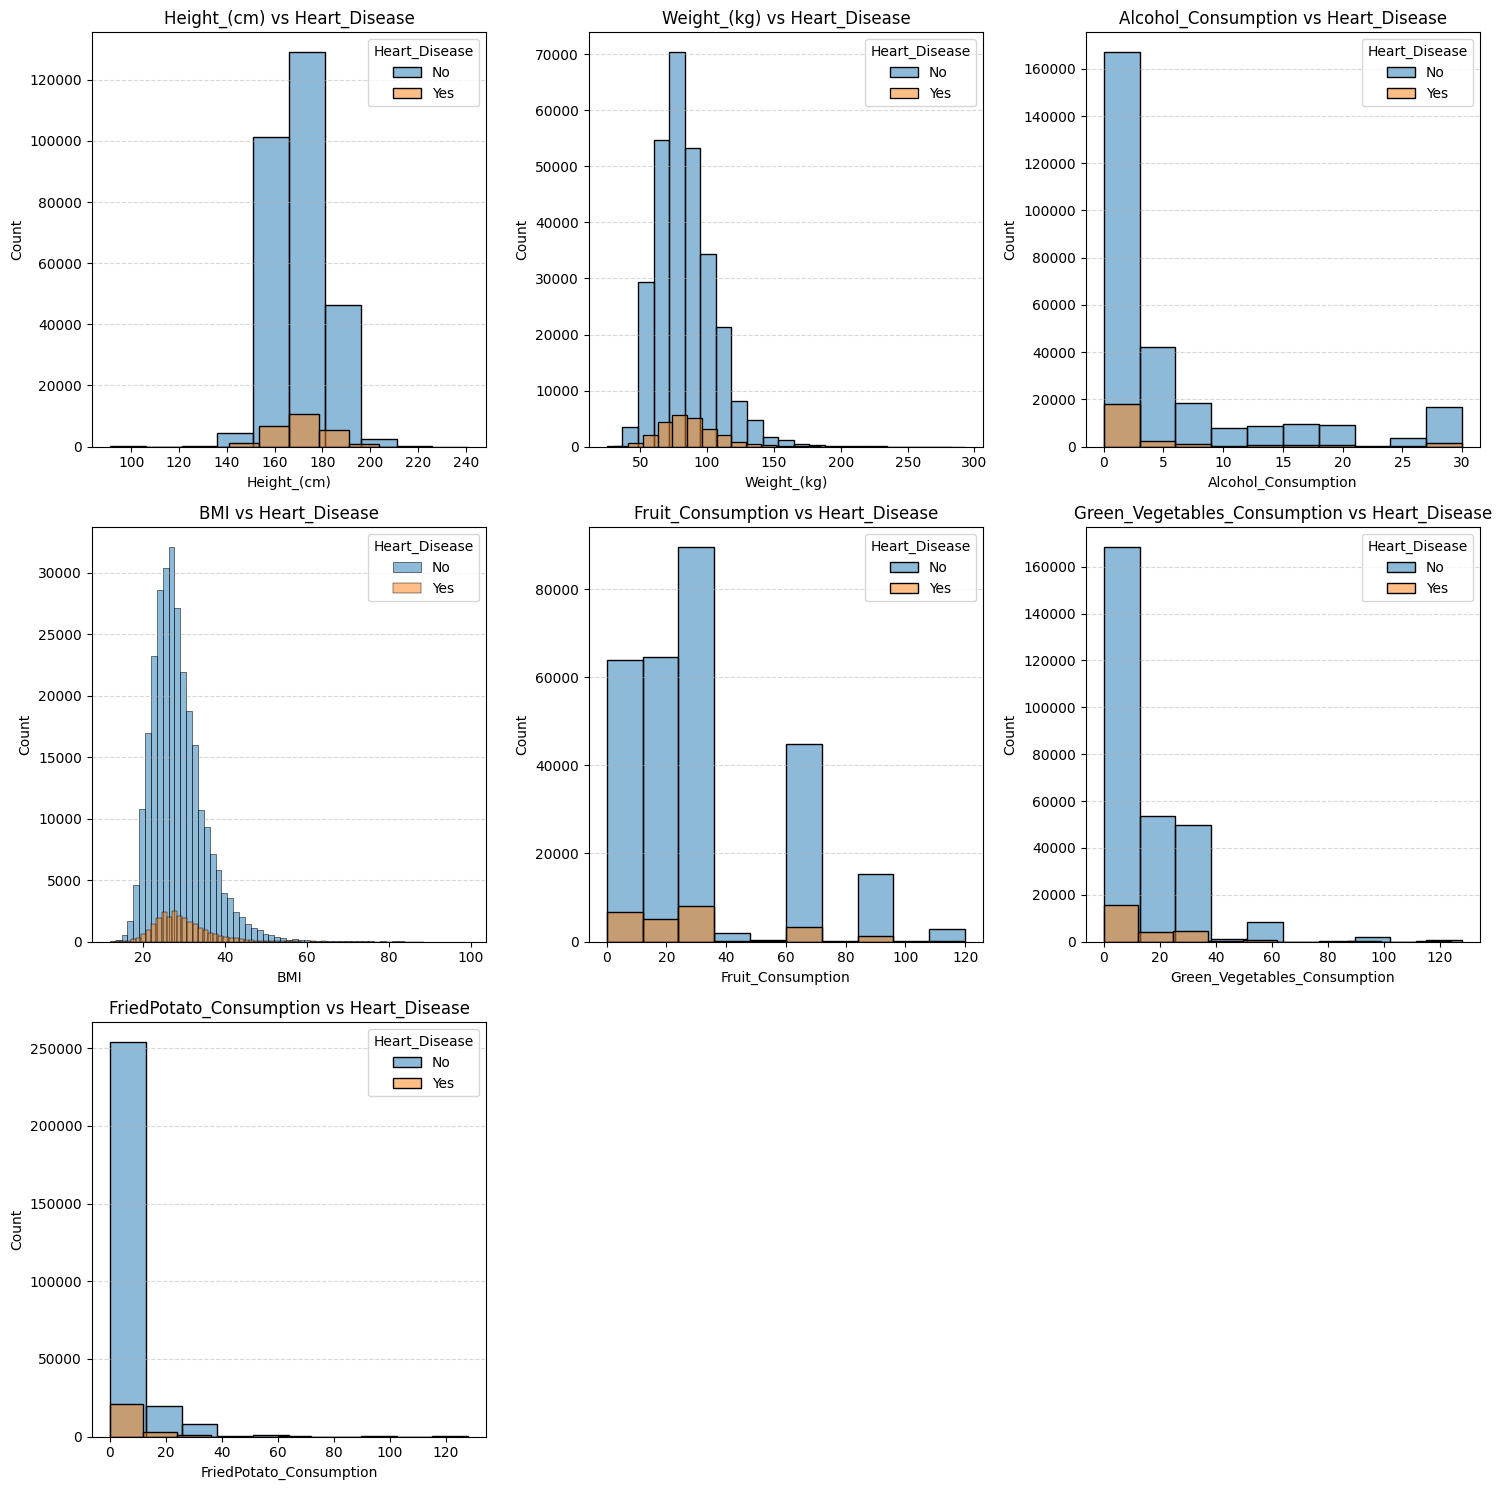

In [ ]:
# Buat grid 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes_flat = axes.flatten()

# Loop setiap kolom
for i, col in enumerate(num_cols):
    ax = axes_flat[i]
    # Hitung jumlah bin berdasarkan sqrt dari jumlah unique, minimal 10 bin
    nunique = df1[col].nunique()
    bins = int(np.ceil(np.sqrt(nunique)))
    bins = max(bins, 10)

    # Plot untuk Heart_Disease = 'No'
    sns.histplot(
        df1[df1['Heart_Disease'] == 'No'][col].dropna(),
        bins=bins,
        label='No',
        alpha=0.5,
        kde=False,
        ax=ax
    )
    # Plot untuk Heart_Disease = 'Yes'
    sns.histplot(
        df1[df1['Heart_Disease'] == 'Yes'][col].dropna(),
        bins=bins,
        label='Yes',
        alpha=0.5,
        kde=False,
        ax=ax
    )

    ax.set_title(f'{col} vs Heart_Disease', fontsize=12)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(title='Heart_Disease')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Matikan sisa subplot (2 sisa dari 9)
for j in range(len(num_cols), 9):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

category col

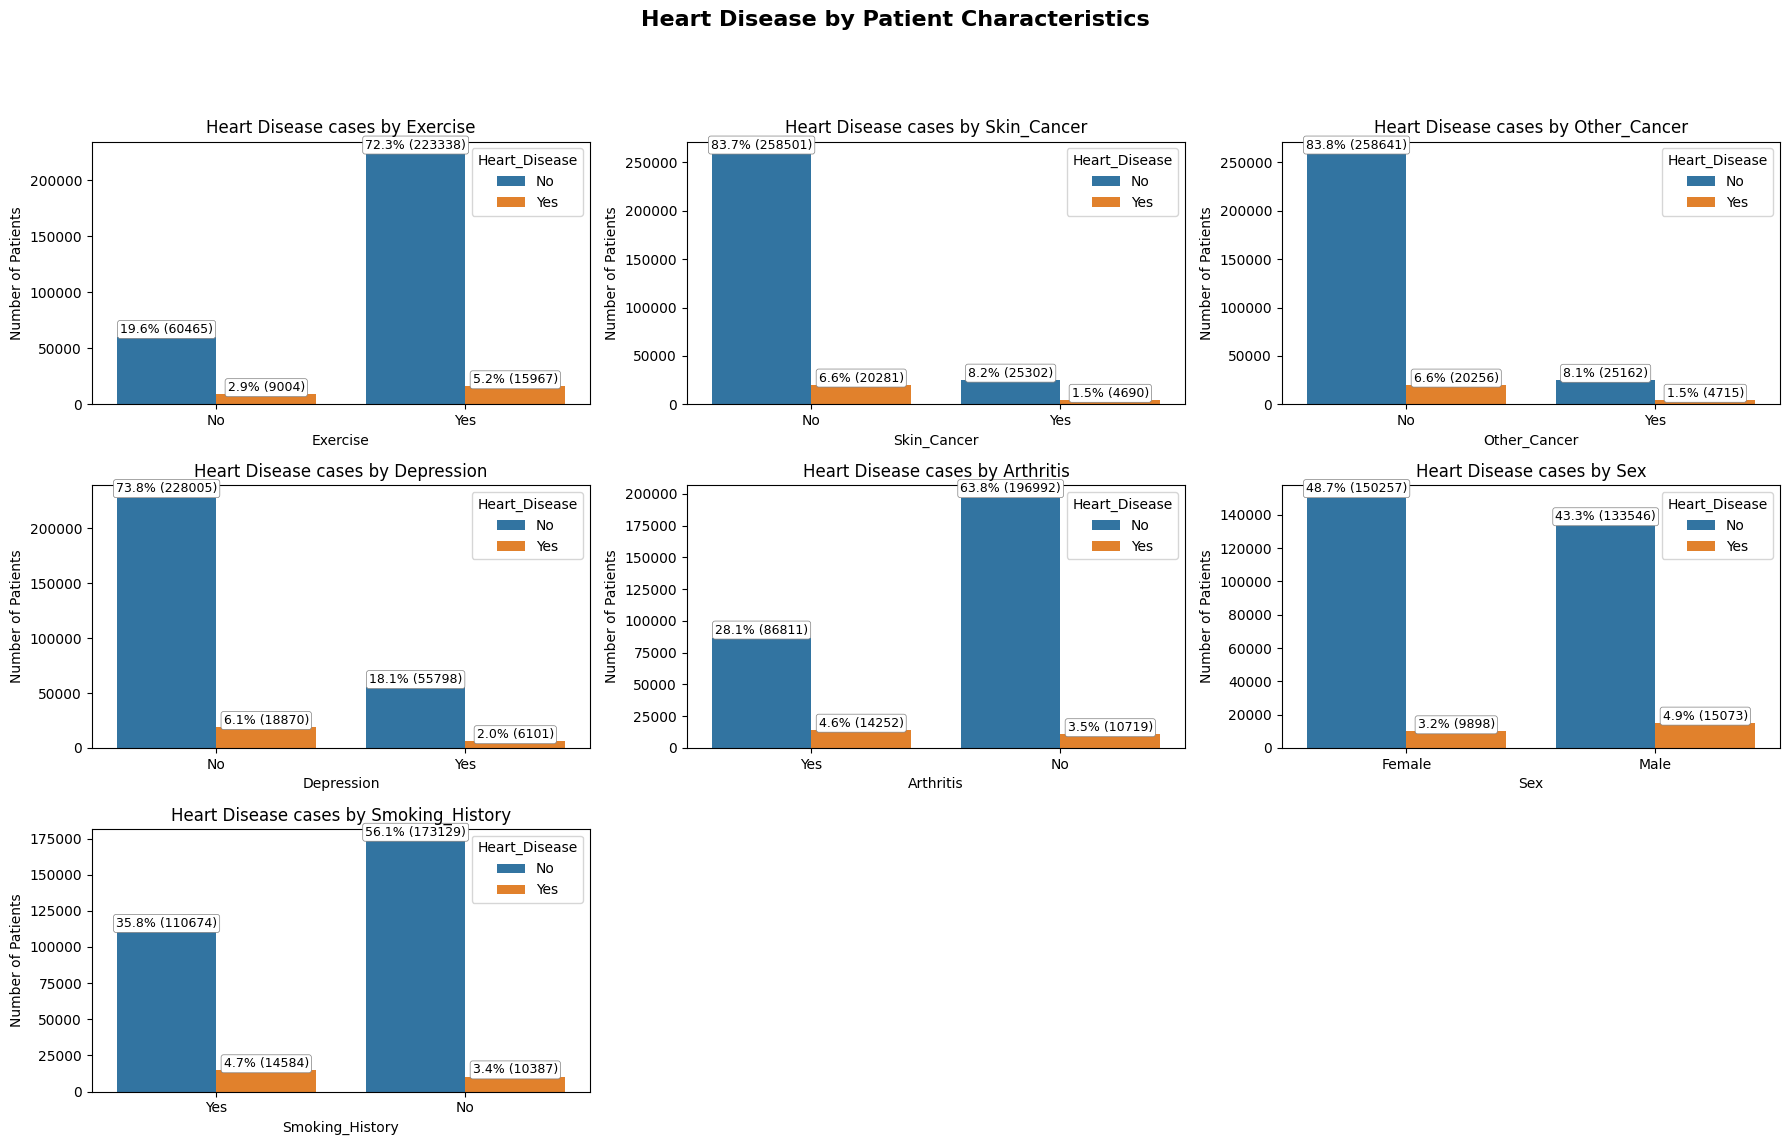

In [ ]:
n_rows, n_cols = 3, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
fig.suptitle("Heart Disease by Patient Characteristics\n", fontsize=16, fontweight='bold')

cat_cols = ['Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression',
            'Arthritis', 'Sex', 'Smoking_History']

total = len(df1)

for i, col in enumerate(cat_cols):
    i_row, i_col = divmod(i, n_cols)
    ax = axes[i_row, i_col]


    rects = sns.countplot(x=col, hue="Heart_Disease", data=df1, ax=ax)


    for p in rects.patches:
        height = p.get_height()
        if height > 0:
            pct = height / total * 100
            ax.text(
                p.get_x() + p.get_width() / 2,
                height * 1.01,
                f"{pct:.1f}% ({int(height)})",
                ha='center',
                va='bottom',
                fontsize=9,
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', linewidth=0.5)
            )

    ax.set_xlabel(col)
    ax.set_ylabel("Number of Patients")
    ax.set_title(f'Heart Disease cases by {col}')

for j in range(len(cat_cols), n_rows * n_cols):
    i_row, i_col = divmod(j, n_cols)
    axes[i_row, i_col].axis('off')

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

ordinal col

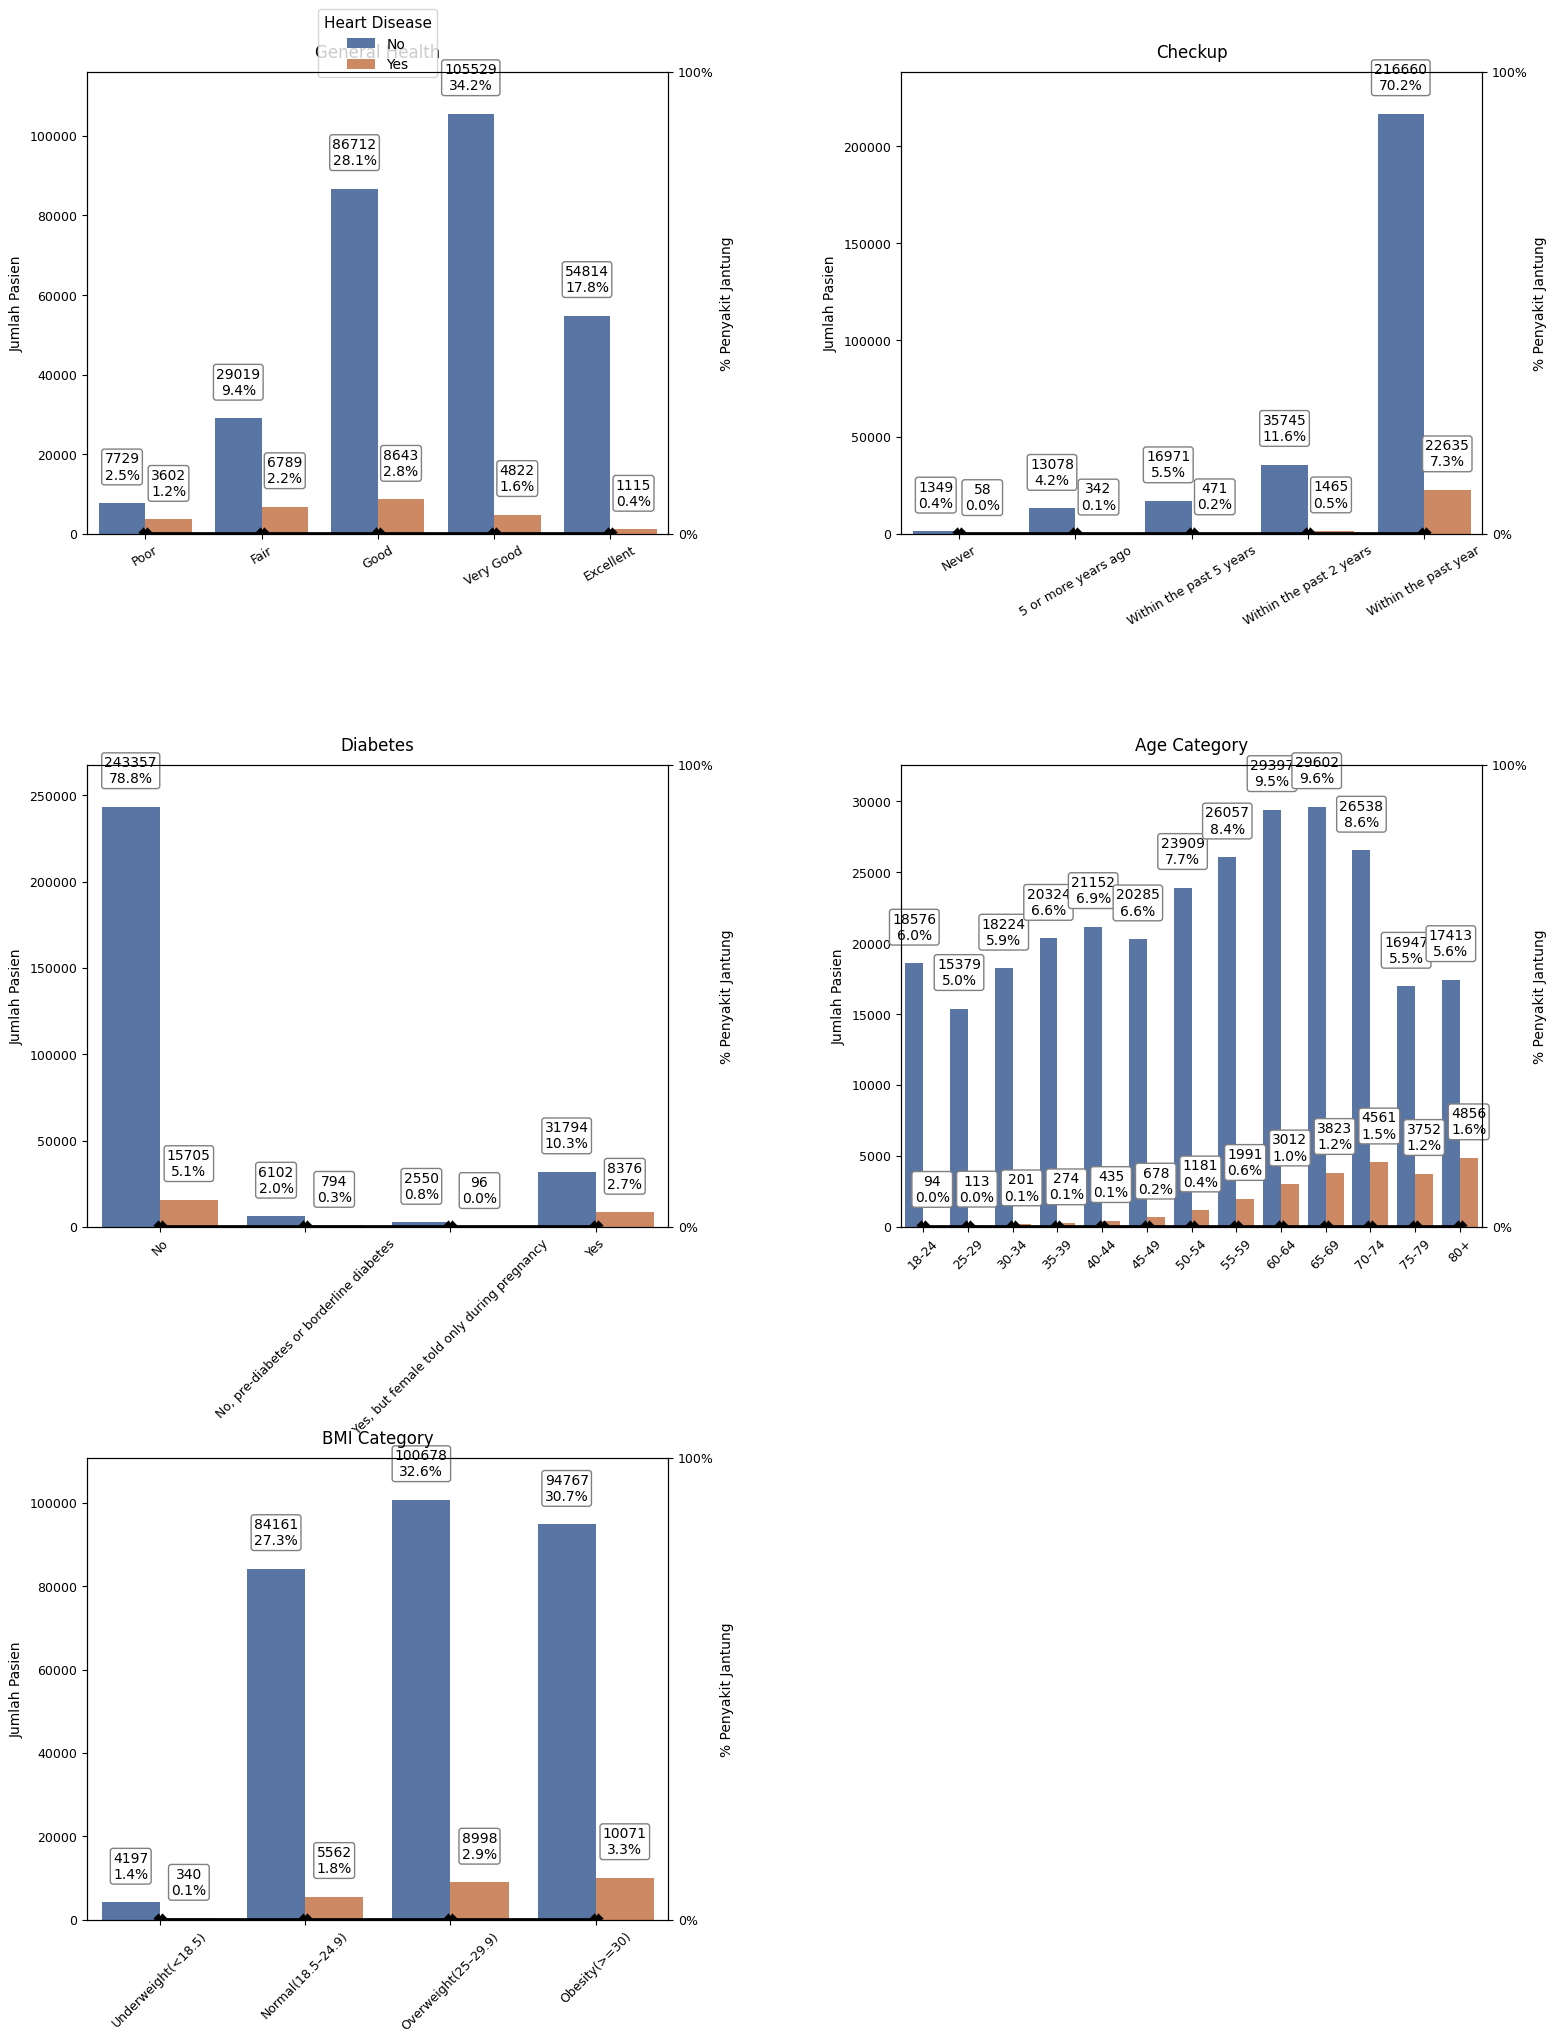

In [ ]:
category_orders = {
    'General_Health': ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
    'Checkup': ['Never', '5 or more years ago', 'Within the past 5 years', 'Within the past 2 years', 'Within the past year'],
    'Diabetes': ['No', 'No, pre-diabetes or borderline diabetes', 'Yes, but female told only during pregnancy', 'Yes'],
    'Age_Category': ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+'],
    'BMI_Category': ['Underweight(<18.5)', 'Normal(18.5–24.9)', 'Overweight(25–29.9)', 'Obesity(>=30)']
}

fig = plt.figure(figsize=(18, 24))
gs = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.4)
palette = {"No": "#4C72B0", "Yes": "#DD8452"}
total = len(df1)

def plot_ordinal(ax, col_name, order_list, show_legend=False, rotate_xticks=30):
    sns.countplot( x=col_name, hue="Heart_Disease", data=df1, order=order_list, palette=palette, ax=ax, dodge=True )
    counts = df1.groupby([col_name, 'Heart_Disease']).size()
    max_count = counts.max() if not counts.empty else 0
    ax.set_ylim(0, max_count * 1.1)
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            pct = h / total * 100
            offset = max_count * 0.05
            ax.text( p.get_x() + p.get_width() / 2, h + offset, f"{int(h)}\n{pct:.1f}%", ha='center', va='bottom', fontsize=10, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2') )
    ax.set_title(col_name.replace('_', ' '), fontsize=12, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel("Jumlah Pasien", fontsize=10)
    ax.tick_params(axis='x', rotation=rotate_xticks, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax2 = ax.twinx()
    sns.pointplot( x=col_name, y="Heart_Disease", data=df1, estimator=lambda x: np.mean(x == 'Yes'), order=order_list, errwidth=0, marker='X', color='black', ax=ax2 )
    ax2.set_ylim(0, 1)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y * 100)}%"))
    ax2.set_ylabel("% Penyakit Jantung", fontsize=10)
    ax2.tick_params(axis='y', labelsize=9)
    ax2.yaxis.tick_right()
    ax2.yaxis.set_label_position('right')
    if show_legend:
        ax.legend( title='Heart Disease', loc='upper center', bbox_to_anchor=(0.5, 1.15), fontsize=10, title_fontsize=11 )
    else:
        ax.get_legend().remove()

ax0 = fig.add_subplot(gs[0, 0])
plot_ordinal( ax=ax0, col_name='General_Health', order_list=category_orders ['General_Health'], show_legend=True, rotate_xticks=30 )

ax1 = fig.add_subplot(gs[0, 1])
plot_ordinal( ax=ax1, col_name='Checkup', order_list=category_orders['Checkup'], show_legend=False, rotate_xticks=30 )

ax2 = fig.add_subplot(gs[1, 0])
plot_ordinal( ax=ax2, col_name='Diabetes', order_list=category_orders['Diabetes'], show_legend=False, rotate_xticks=45 )

ax3 = fig.add_subplot(gs[1, 1])
plot_ordinal( ax=ax3, col_name='Age_Category', order_list=category_orders['Age_Category'], show_legend=False, rotate_xticks=45 )

ax4 = fig.add_subplot(gs[2, 0])
plot_ordinal( ax=ax4, col_name='BMI_Category', order_list=category_orders['BMI_Category'], show_legend=False, rotate_xticks=45 )

ax5 = fig.add_subplot

multivariate analys

numerik col

category col

ordinal col

data statistik numerik col

In [ ]:
df1.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Height_(cm),308774.0,170.615220,10.658452,91.00,163.00,170.00,178.00,241.00
Weight_(kg),308774.0,83.590399,21.344664,24.95,68.04,81.65,95.25,293.02
BMI,308774.0,28.626813,6.522810,12.02,24.21,27.44,31.85,99.33
Alcohol_Consumption,308774.0,5.097557,8.200434,0.00,0.00,1.00,6.00,30.00
Fruit_Consumption,308774.0,29.834290,24.877812,0.00,12.00,30.00,30.00,120.00
Green_Vegetables_Consumption,308774.0,15.109517,14.926912,0.00,4.00,12.00,20.00,128.00
FriedPotato_Consumption,308774.0,6.297237,8.583837,0.00,2.00,4.00,8.00,128.00


box plot

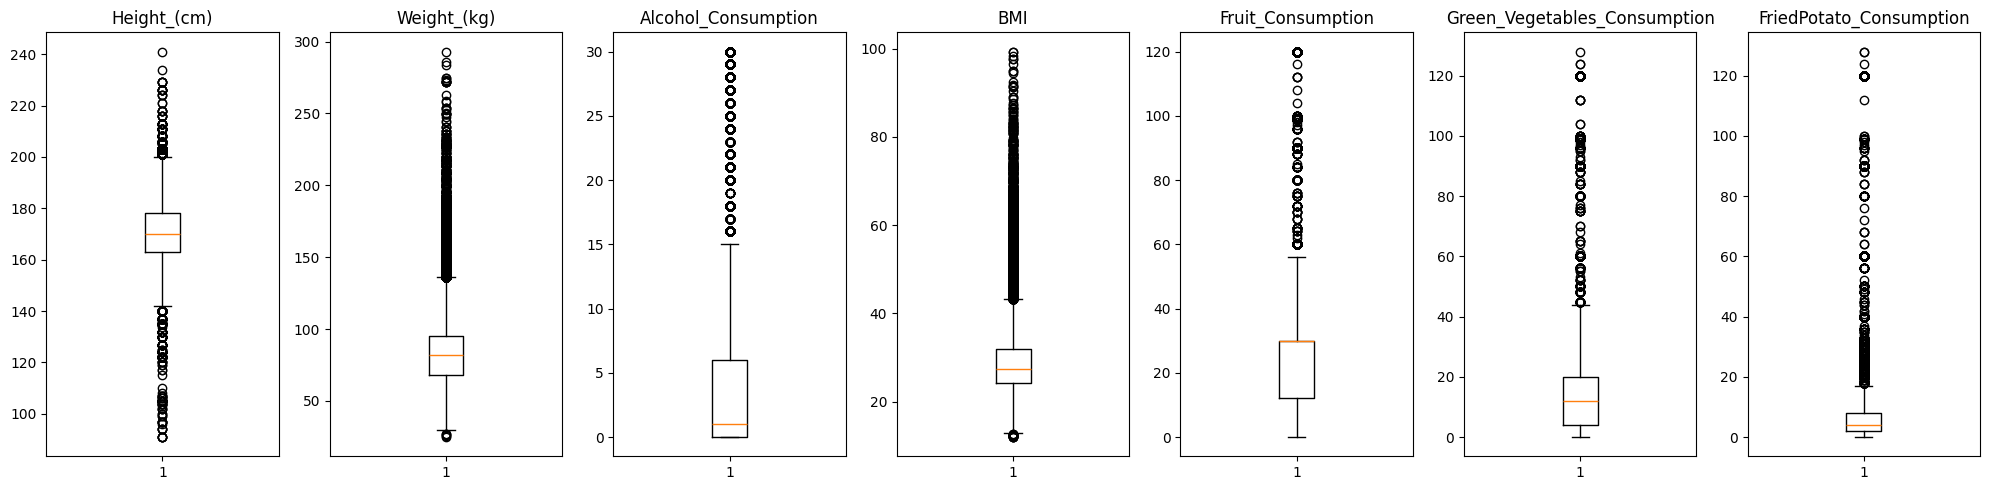

In [ ]:
fig, axs = plt.subplots(1, 7, figsize=(20, 5))

axs[0].boxplot(df1['Height_(cm)'])
axs[0].set_title('Height_(cm)')

axs[1].boxplot(df1['Weight_(kg)'])
axs[1].set_title('Weight_(kg)')

axs[2].boxplot(df1['Alcohol_Consumption'])
axs[2].set_title('Alcohol_Consumption')

axs[3].boxplot(df1['BMI'])
axs[3].set_title('BMI')

axs[4].boxplot(df1['Fruit_Consumption'])
axs[4].set_title('Fruit_Consumption')

axs[5].boxplot(df1['Green_Vegetables_Consumption'])
axs[5].set_title('Green_Vegetables_Consumption')

axs[6].boxplot(df1['FriedPotato_Consumption'])
axs[6].set_title('FriedPotato_Consumption')

plt.tight_layout()
plt.show()


## Train Model dan Test Model

Copy dataset

In [ ]:
df2=df.copy()

In [ ]:
df2.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [ ]:
df2.tail()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168.0,81.65,29.05,No,4.0,30.0,8.0,0.0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180.0,69.85,21.48,No,8.0,15.0,60.0,4.0
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157.0,61.23,24.69,Yes,4.0,40.0,8.0,4.0
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183.0,79.38,23.73,No,3.0,30.0,12.0,0.0
308853,Excellent,Within the past year,Yes,No,No,No,No,No,No,Female,45-49,160.0,81.19,31.71,No,1.0,5.0,12.0,1.0


feature enginering data

In [ ]:
df2['BMI_Category'] = pd.cut(df2['BMI'], bins=[0, 18.5, 25, 30, np.inf], labels=['Underweight(<18.5)', 'Normal(18.5–24.9)', 'Overweight(25–29.9)', 'Obesity(>=30)'], right=False).astype('object')

Preprocessing

In [ ]:
duplicates = df2[df2.duplicated()]
print("Total Duplicates rows observed:", duplicates.shape[0])
print("Dropping duplicates")
print("Shape before dropping duplicates: ", df2.shape[0])
df2.drop_duplicates(inplace=True)
df2.reset_index(drop=True, inplace=True)
print("Shape after dropping duplicates: ", df2.shape[0])
duplicates_after_drop = df2[df2.duplicated()]
print("Total Duplicates rows observed after dropping:", duplicates_after_drop.shape[0])

Total Duplicates rows observed: 80
Dropping duplicates
Shape before dropping duplicates:  308854
Shape after dropping duplicates:  308774
Total Duplicates rows observed after dropping: 0


In [ ]:
total = df2.isnull().sum().sort_values(ascending=False)
percent = (df2.isnull().sum() / df2.isnull().count()).sort_values(ascending=False)
missing_df2 = pd.concat([total, percent*100], axis=1, keys=["Total", "Percent(%)"])
missing_df2

,Total,Percent(%)
General_Health,0,0.0
Checkup,0,0.0
Exercise,0,0.0
Heart_Disease,0,0.0
Skin_Cancer,0,0.0
Other_Cancer,0,0.0
Depression,0,0.0
Diabetes,0,0.0
Arthritis,0,0.0
Sex,0,0.0


Encoding

In [ ]:
binary_cols = ['Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer','Depression', 'Arthritis', 'Sex', 'Smoking_History']

In [ ]:
ordinal_cols = {
    'General_Health': ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
    'Checkup': ['Never', '5 or more years ago', 'Within the past 5 years',
                'Within the past 2 years', 'Within the past year'],
    'Diabetes': ['No', 'No, pre-diabetes or borderline diabetes',
                 'Yes, but female told only during pregnancy', 'Yes'],
    'Age_Category': ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49',
                     '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+'],
    'BMI_Category': ['Underweight(<18.5)', 'Normal(18.5–24.9)', 'Overweight(25–29.9)',
                     'Obesity(>=30)']}

In [ ]:
for col in binary_cols:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col])
    print(f"{col} mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Exercise mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Heart_Disease mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Skin_Cancer mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Other_Cancer mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Depression mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Arthritis mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Sex mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
Smoking_History mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


In [ ]:
for col, categories in ordinal_cols.items():
    oe = OrdinalEncoder(categories=[categories])
    df2[col] = oe.fit_transform(df2[[col]]).astype(int)
    print(f"{col} mapping: {dict(zip(categories, range(len(categories))))}")

General_Health mapping: {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very Good': 3, 'Excellent': 4}
Checkup mapping: {'Never': 0, '5 or more years ago': 1, 'Within the past 5 years': 2, 'Within the past 2 years': 3, 'Within the past year': 4}
Diabetes mapping: {'No': 0, 'No, pre-diabetes or borderline diabetes': 1, 'Yes, but female told only during pregnancy': 2, 'Yes': 3}
Age_Category mapping: {'18-24': 0, '25-29': 1, '30-34': 2, '35-39': 3, '40-44': 4, '45-49': 5, '50-54': 6, '55-59': 7, '60-64': 8, '65-69': 9, '70-74': 10, '75-79': 11, '80+': 12}
BMI_Category mapping: {'Underweight(<18.5)': 0, 'Normal(18.5–24.9)': 1, 'Overweight(25–29.9)': 2, 'Obesity(>=30)': 3}


Correlation matrix

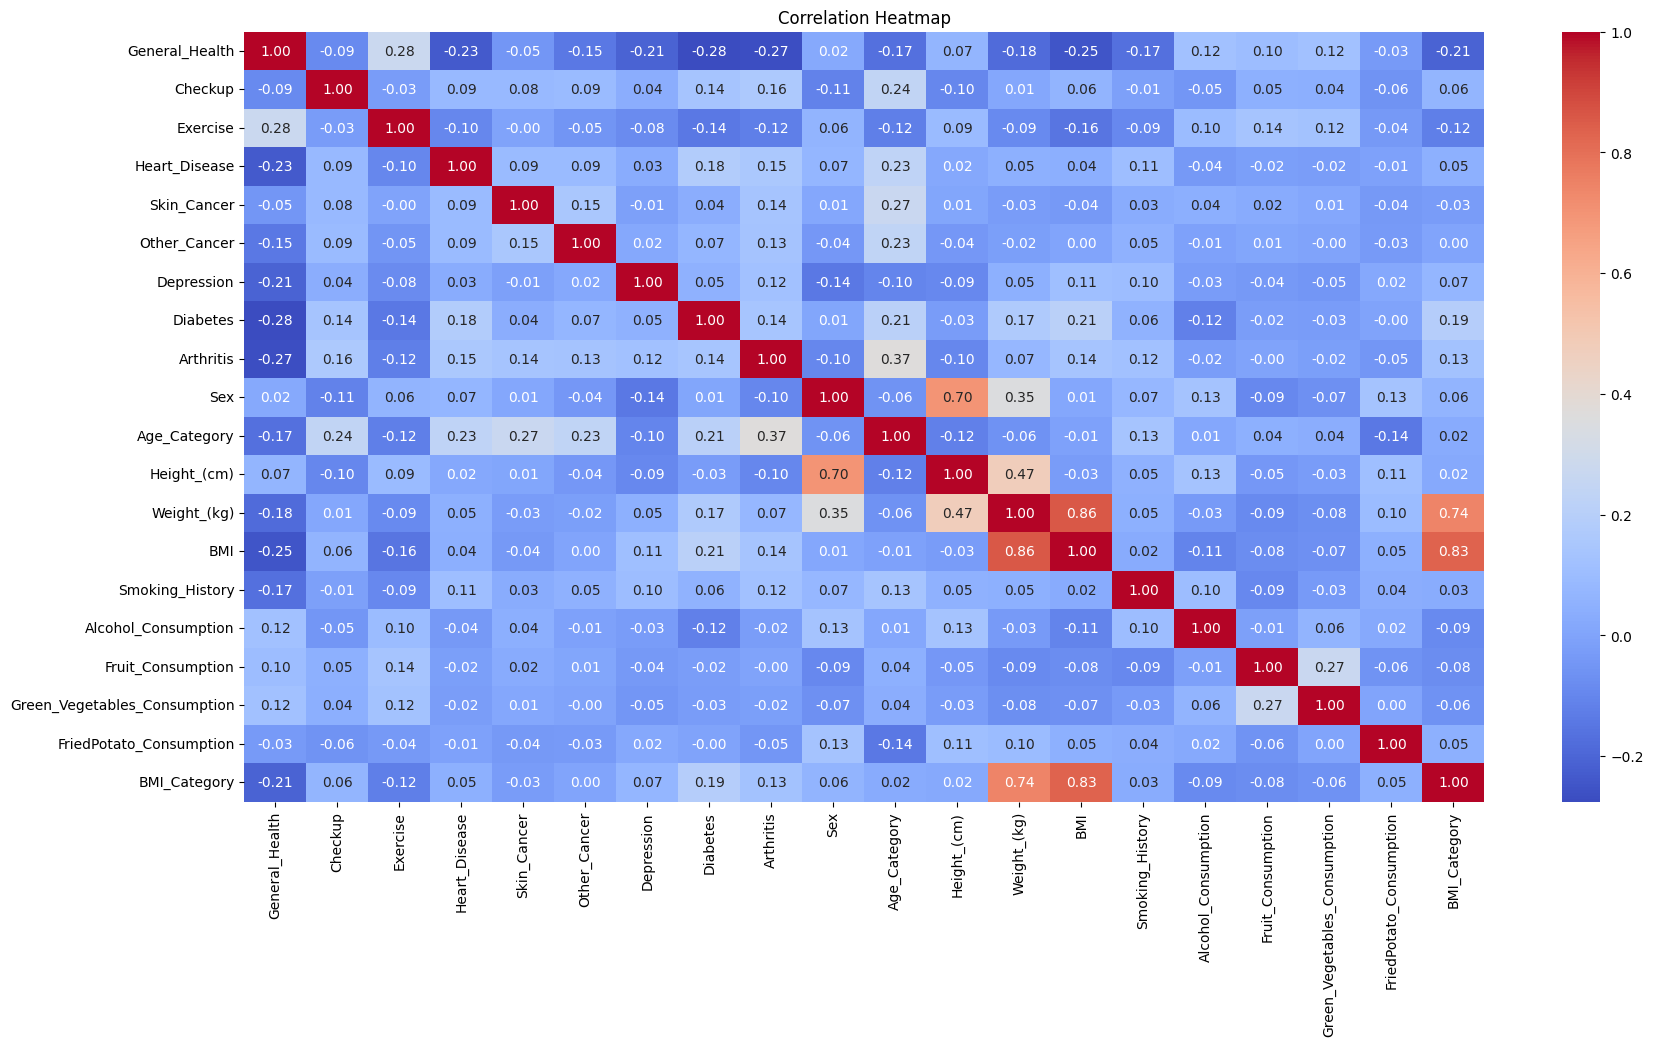

In [ ]:
correlation_matrix = df2.corr()

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

feature selection

In [ ]:
features = ['Age_Category', 'Diabetes', 'Arthritis', 'General_Health', 'Exercise', 'BMI', 'Smoking_History', 'Sex']
target = 'Heart_Disease'

train test split

In [ ]:
X = df2[features]
y = df2[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote

In [ ]:
smote = BorderlineSMOTE(sampling_strategy=1.0 , random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_train_smote, y_train_smote, test_size=0.2, random_state=42)

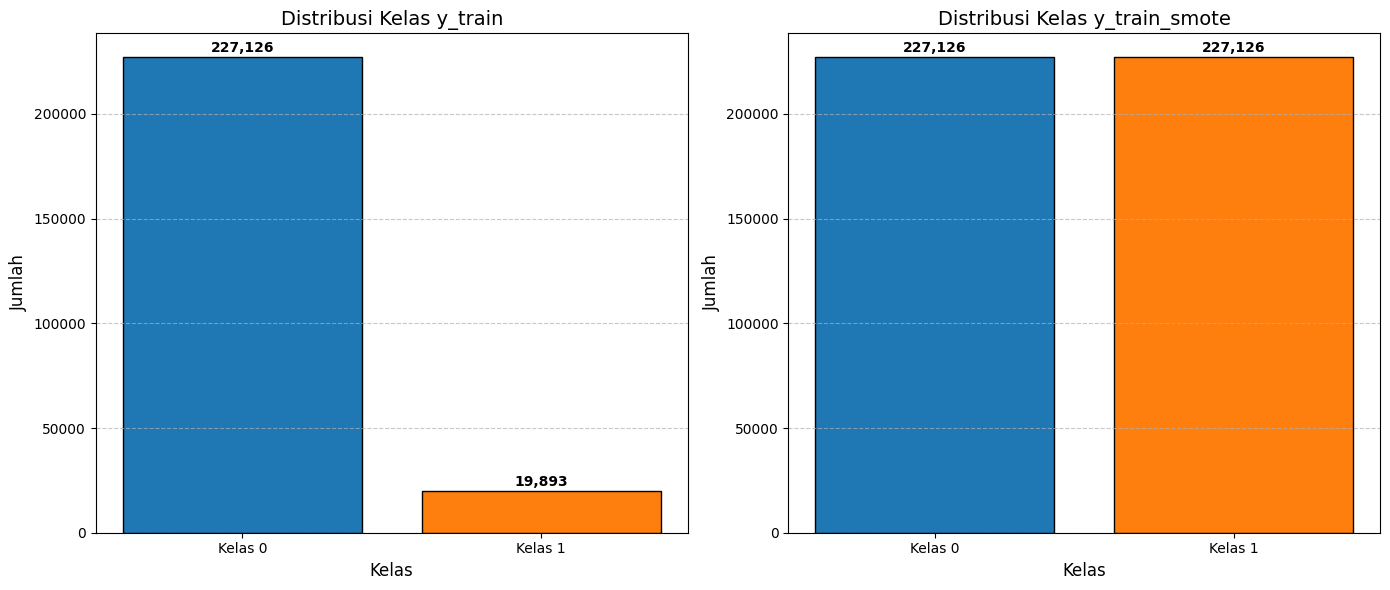

In [ ]:
def plot_class_distribution(y_data, title, ax, colors):
    counter = Counter(y_data)
    labels = ['Kelas 0', 'Kelas 1']
    values = [counter[0], counter[1]]

    bars = ax.bar(labels, values, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Jumlah', fontsize=12)
    ax.set_xlabel('Kelas', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Tambahkan label di atas bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 1000, f'{yval:,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_class_distribution(y_train, 'Distribusi Kelas y_train', axes[0], ['#1f77b4', '#ff7f0e'])
plot_class_distribution(y_train_smote, 'Distribusi Kelas y_train_smote', axes[1], ['#1f77b4', '#ff7f0e'])

plt.tight_layout()
plt.show()

In [ ]:
sampling_strategy = {0: 5078, 1: 5078}

# Inisialisasi RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)

# Terapkan under-sampling pada data test
X_test_resampled, y_test_resampled = rus.fit_resample(X_test, y_test)

# Verifikasi distribusi kelas setelah under-sampling
print("Distribusi kelas setelah under-sampling:")
print(y_test_resampled.value_counts())

Distribusi kelas setelah under-sampling:
Heart_Disease
0    5078
1    5078
Name: count, dtype: int64


# Random forest

In [ ]:
rf1 = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=8,
    min_samples_leaf=6,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42
)
rf1.fit(X_train_smote, y_train_smote)

rf1_predictions_train = rf1.predict(X_train_smote)
rf1_predictions_test = rf1.predict(X_test_resampled)

accuracy_train = accuracy_score(y_train_smote, rf1_predictions_train)
print(f"Random Forest Classifier Train Accuracy: {accuracy_train:.2f}")
print("Random Forest Classifier Train Classification Report:")
print(classification_report(y_train_smote, rf1_predictions_train))
print("Random Forest Classifier Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, rf1_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, rf1_predictions_test)
print(f"Random Forest Classifier Test Accuracy: {accuracy_test:.2f}")
print("Random Forest Classifier Test Classification Report:")
print(classification_report(y_test_resampled, rf1_predictions_test))
print("Random Forest Classifier Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, rf1_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

Random Forest Classifier Train Accuracy: 0.85
Random Forest Classifier Train Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84    227126
           1       0.82      0.91      0.86    227126

    accuracy                           0.85    454252
   macro avg       0.86      0.85      0.85    454252
weighted avg       0.86      0.85      0.85    454252

Random Forest Classifier Train Confusion Matrix:
[[181590  45536]
 [ 21458 205668]]
Random Forest Classifier Test Accuracy: 0.85
Random Forest Classifier Test Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      5078
           1       0.82      0.90      0.86      5078

    accuracy                           0.85     10156
   macro avg       0.86      0.85      0.85     10156
weighted avg       0.86      0.85      0.85     10156

Random Forest Classifier Test Confusion Matrix:
[[4056 1022]
 [ 

# feature importance rf1

In [ ]:
print("Melatih model Random Forest...")
rf1 = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=8,
    min_samples_leaf=6,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42
)
rf1.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")

accuracy_test = rf1.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model di Data Tes: {accuracy_test:.4f}\n")

print("Menghitung Permutation Importance pada data tes...")
result = permutation_importance(
    rf1,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
print("Perhitungan selesai.\n")

sorted_importances_idx = result.importances_mean.argsort()[::-1]

importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})

importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (TERURUT)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")

pd.options.display.float_format = '{:,.4f}'.format
print(importance_summary.to_string())
print("="*80)

Melatih model Random Forest...
Model selesai dilatih.
Akurasi Awal Model di Data Tes: 0.8516

Menghitung Permutation Importance pada data tes...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (TERURUT)
                  Akurasi Awal Model: 0.8516
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.2010   0.0034                 0.6506
1   General_Health             0.1589   0.0030                 0.6927
2              BMI             0.0962   0.0026                 0.7555
3              Sex             0.0649   0.0018                 0.7867
4         Diabetes             0.0544   0.0022                 0.7972
5  Smoking_History             0.0505   0.0021                 0.8011
6        Arthritis             0.0479   0.0013                 0.8037
7         Exercise             0.0444   0.0023                 0.8073


In [ ]:
rf2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
rf2.fit(X_train_smote, y_train_smote)

rf2_predictions_train = rf2.predict(X_train_smote)
rf2_predictions_test = rf2.predict(X_test_resampled)

accuracy_train = accuracy_score(y_train_smote, rf2_predictions_train)
print(f"Random Forest Classifier Train Accuracy: {accuracy_train:.2f}")
print("Random Forest Classifier Train Classification Report:")
print(classification_report(y_train_smote, rf2_predictions_train))
print("Random Forest Classifier Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, rf2_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, rf2_predictions_test)
print(f"Random Forest Classifier Test Accuracy: {accuracy_test:.2f}")
print("Random Forest Classifier Test Classification Report:")
print(classification_report(y_test_resampled, rf2_predictions_test))
print("Random Forest Classifier Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, rf2_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

Random Forest Classifier Train Accuracy: 0.94
Random Forest Classifier Train Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94    227126
           1       0.93      0.96      0.94    227126

    accuracy                           0.94    454252
   macro avg       0.94      0.94      0.94    454252
weighted avg       0.94      0.94      0.94    454252

Random Forest Classifier Train Confusion Matrix:
[[209676  17450]
 [  8941 218185]]
Random Forest Classifier Test Accuracy: 0.94
Random Forest Classifier Test Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      5078
           1       0.92      0.96      0.94      5078

    accuracy                           0.94     10156
   macro avg       0.94      0.94      0.94     10156
weighted avg       0.94      0.94      0.94     10156

Random Forest Classifier Test Confusion Matrix:
[[4667  411]
 [ 

# feature importance rf2

In [ ]:
print("Melatih model Random Forest (rf2)...")

rf2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
rf2.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")


accuracy_test = rf2.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model (rf2) di Data Tes: {accuracy_test:.4f}\n")


print("Menghitung Permutation Importance pada data tes untuk model rf2...")
result = permutation_importance(
    rf2,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
print("Perhitungan selesai.\n")

sorted_importances_idx = result.importances_mean.argsort()[::-1]

importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})

importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (MODEL RF2)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")
pd.options.display.float_format = '{:,.4f}'.format
print(importance_summary.to_string())
print("="*80)


Melatih model Random Forest (rf2)...
Model selesai dilatih.
Akurasi Awal Model (rf2) di Data Tes: 0.9396

Menghitung Permutation Importance pada data tes untuk model rf2...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (MODEL RF2)
                  Akurasi Awal Model: 0.9396
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.3094   0.0043                 0.6302
1              BMI             0.2822   0.0029                 0.6574
2   General_Health             0.2526   0.0026                 0.6871
3              Sex             0.1479   0.0024                 0.7917
4  Smoking_History             0.1359   0.0030                 0.8037
5        Arthritis             0.1354   0.0033                 0.8042
6         Diabetes             0.1255   0.0014                 0.8141
7         Exercise             0.1187   0.0022                 0.8210


In [ ]:
rf3 = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=3,
    max_features='log2',
    class_weight='balanced',
    random_state=42
)
rf3.fit(X_train_smote, y_train_smote)

rf3_predictions_train = rf3.predict(X_train_smote)
rf3_predictions_test = rf3.predict(X_test_resampled)

accuracy_train = accuracy_score(y_train_smote, rf3_predictions_train)
print(f"Random Forest Classifier Train Accuracy: {accuracy_train:.2f}")
print("Random Forest Classifier Train Classification Report:")
print(classification_report(y_train_smote, rf3_predictions_train))
print("Random Forest Classifier Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, rf3_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, rf3_predictions_test)
print(f"Random Forest Classifier Test Accuracy: {accuracy_test:.2f}")
print("Random Forest Classifier Test Classification Report:")
print(classification_report(y_test_resampled, rf3_predictions_test))
print("Random Forest Classifier Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, rf3_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

Random Forest Classifier Train Accuracy: 0.91
Random Forest Classifier Train Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91    227126
           1       0.88      0.95      0.91    227126

    accuracy                           0.91    454252
   macro avg       0.91      0.91      0.91    454252
weighted avg       0.91      0.91      0.91    454252

Random Forest Classifier Train Confusion Matrix:
[[198857  28269]
 [ 12092 215034]]
Random Forest Classifier Test Accuracy: 0.91
Random Forest Classifier Test Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.91      5078
           1       0.88      0.95      0.91      5078

    accuracy                           0.91     10156
   macro avg       0.91      0.91      0.91     10156
weighted avg       0.91      0.91      0.91     10156

Random Forest Classifier Test Confusion Matrix:
[[4432  646]
 [ 

# feature importance rf3

In [ ]:
rf3 = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=3,
    max_features='log2',
    class_weight='balanced',
    random_state=42
)
rf3.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")

accuracy_test = rf3.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model (rf3) di Data Tes: {accuracy_test:.4f}\n")

print("Menghitung Permutation Importance pada data tes untuk model rf3...")
result = permutation_importance(
    rf3,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
print("Perhitungan selesai.\n")


sorted_importances_idx = result.importances_mean.argsort()[::-1]

importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})

importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

pd.options.display.float_format = '{:,.4f}'.format

print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (MODEL RF3)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")
print(importance_summary.to_string())
print("="*80)

Model selesai dilatih.
Akurasi Awal Model (rf3) di Data Tes: 0.9095

Menghitung Permutation Importance pada data tes untuk model rf3...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (MODEL RF3)
                  Akurasi Awal Model: 0.9095
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.2788   0.0054                 0.6307
1   General_Health             0.2251   0.0028                 0.6844
2              BMI             0.2214   0.0028                 0.6881
3              Sex             0.1228   0.0024                 0.7868
4  Smoking_History             0.1111   0.0023                 0.7985
5        Arthritis             0.1062   0.0023                 0.8033
6         Diabetes             0.1043   0.0013                 0.8053
7         Exercise             0.0953   0.0022                 0.8142


Visualisasi perbandingan model

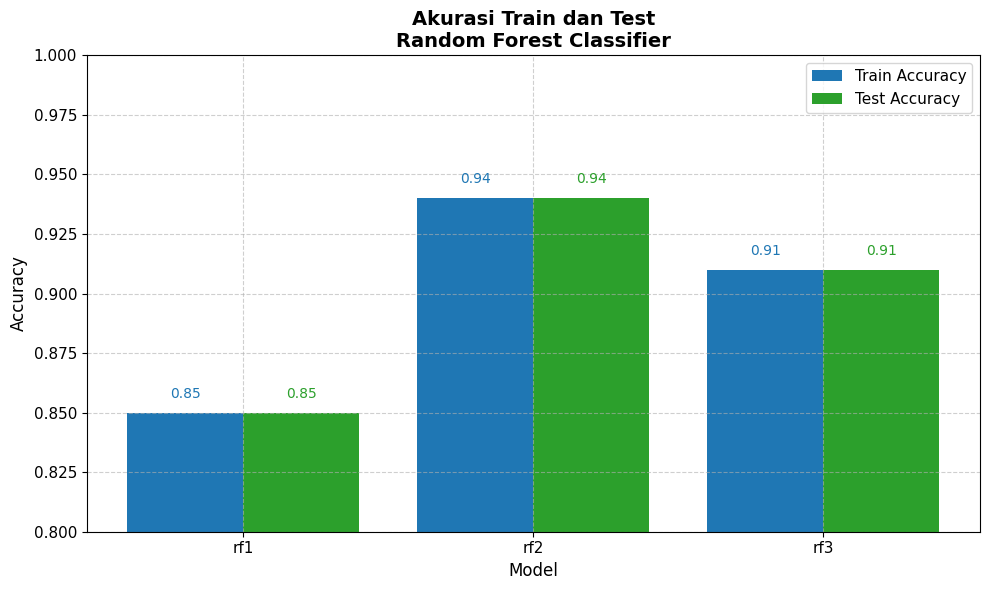

In [ ]:
models = ['rf1', 'rf2', 'rf3']
train_accuracies = [0.85, 0.94, 0.91]
test_accuracies = [0.85, 0.94, 0.91]

bar_width = 0.4
x = np.arange(len(models))
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, train_accuracies, bar_width, label='Train Accuracy', color='#1f77b4')
plt.bar(x + bar_width/2, test_accuracies, bar_width, label='Test Accuracy', color='#2ca02c')

for i, (xt, yt) in enumerate(zip(x, train_accuracies)):
    plt.text(xt - bar_width/2, yt + 0.005, f'{yt:.2f}', ha='center', va='bottom', color='#1f77b4')
for i, (xt, yt) in enumerate(zip(x, test_accuracies)):
    plt.text(xt + bar_width/2, yt + 0.005, f'{yt:.2f}', ha='center', va='bottom', color='#2ca02c')

plt.xticks(x, models, fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Akurasi Train dan Test\nRandom Forest Classifier', fontsize=14, fontweight='bold')
plt.ylim(0.80, 1.00)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

# Catboost

In [ ]:
cb1 = CatBoostClassifier(
    iterations=400,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced'
)
cb1.fit(X_train_smote, y_train_smote)

cb1_predictions_train = cb1.predict(X_train_smote)
cb1_predictions_test = cb1.predict(X_test_resampled)

accuracy_train = accuracy_score(y_train_smote, cb1_predictions_train)
print(f"CatBoost Classifier Train Accuracy: {accuracy_train:.2f}")
print("CatBoost Classifier Train Classification Report:")
print(classification_report(y_train_smote, cb1_predictions_train))
print("CatBoost Classifier Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, cb1_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, cb1_predictions_test)
print(f"CatBoost Classifier Test Accuracy: {accuracy_test:.2f}")
print("CatBoost Classifier Test Classification Report:")
print(classification_report(y_test_resampled, cb1_predictions_test))
print("CatBoost Classifier Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, cb1_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

CatBoost Classifier Train Accuracy: 0.80
CatBoost Classifier Train Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.75      0.79    227126
           1       0.77      0.86      0.81    227126

    accuracy                           0.80    454252
   macro avg       0.81      0.80      0.80    454252
weighted avg       0.81      0.80      0.80    454252

CatBoost Classifier Train Confusion Matrix:
[[169608  57518]
 [ 31994 195132]]
CatBoost Classifier Test Accuracy: 0.80
CatBoost Classifier Test Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79      5078
           1       0.77      0.86      0.81      5078

    accuracy                           0.80     10156
   macro avg       0.81      0.80      0.80     10156
weighted avg       0.81      0.80      0.80     10156

CatBoost Classifier Test Confusion Matrix:
[[3782 1296]
 [ 696 4382]]
Selisih Akurasi: 0.

# feature importance

In [ ]:
cb1 = CatBoostClassifier(
    iterations=400,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=0, # verbose=0 untuk menonaktifkan output saat training
    auto_class_weights='Balanced'
)
cb1.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")

accuracy_test = cb1.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model (cb1) di Data Tes: {accuracy_test:.4f}\n")


print("Menghitung Permutation Importance pada data tes untuk model CatBoost...")
result = permutation_importance(
    cb1,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1, # Gunakan semua core CPU
    scoring='accuracy'
)
print("Perhitungan selesai.\n")

sorted_importances_idx = result.importances_mean.argsort()[::-1]

importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})

importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

pd.options.display.float_format = '{:,.4f}'.format
print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (MODEL CATBOOST)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")
print(importance_summary.to_string())
print("="*80)

Model selesai dilatih.
Akurasi Awal Model (cb1) di Data Tes: 0.8038

Menghitung Permutation Importance pada data tes untuk model CatBoost...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (MODEL CATBOOST)
                  Akurasi Awal Model: 0.8038
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.1374   0.0043                 0.6664
1   General_Health             0.0985   0.0035                 0.7052
2              BMI             0.0270   0.0017                 0.7768
3              Sex             0.0242   0.0014                 0.7796
4         Diabetes             0.0161   0.0013                 0.7877
5  Smoking_History             0.0077   0.0016                 0.7960
6        Arthritis             0.0056   0.0008                 0.7982
7         Exercise             0.0044   0.0007                 0.7993


In [ ]:
cb2 = CatBoostClassifier(
    iterations=800,
    depth=12,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=3
)
cb2.fit(X_train_smote, y_train_smote)
cb2_predictions_train = cb2.predict(X_train_smote)
cb2_predictions_test = cb2.predict(X_test_resampled)

accuracy_train = accuracy_score(y_train_smote, cb2_predictions_train)
print(f"CatBoost Classifier Train Accuracy: {accuracy_train:.2f}")
print("CatBoost Classifier Train Classification Report:")
print(classification_report(y_train_smote, cb2_predictions_train))
print("CatBoost Classifier Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, cb2_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, cb2_predictions_test)
print(f"CatBoost Classifier Test Accuracy: {accuracy_test:.2f}")
print("CatBoost Classifier Test Classification Report:")
print(classification_report(y_test_resampled, cb2_predictions_test))
print("CatBoost Classifier Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, cb2_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

CatBoost Classifier Train Accuracy: 0.81
CatBoost Classifier Train Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.76      0.80    227126
           1       0.78      0.87      0.82    227126

    accuracy                           0.81    454252
   macro avg       0.82      0.81      0.81    454252
weighted avg       0.82      0.81      0.81    454252

CatBoost Classifier Train Confusion Matrix:
[[171584  55542]
 [ 29624 197502]]
CatBoost Classifier Test Accuracy: 0.81
CatBoost Classifier Test Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.75      0.80      5078
           1       0.78      0.87      0.82      5078

    accuracy                           0.81     10156
   macro avg       0.82      0.81      0.81     10156
weighted avg       0.82      0.81      0.81     10156

CatBoost Classifier Test Confusion Matrix:
[[3818 1260]
 [ 653 4425]]
Selisih Akurasi: 0.

# feature importance

In [ ]:
print("Melatih model CatBoost (cb2)...")

cb2 = CatBoostClassifier(
    iterations=800,
    depth=12,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=3
)
cb2.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")

accuracy_test = cb2.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model (cb2) di Data Tes: {accuracy_test:.4f}\n")

print("Menghitung Permutation Importance pada data tes untuk model CatBoost (cb2)...")
result = permutation_importance(
    cb2,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
print("Perhitungan selesai.\n")


sorted_importances_idx = result.importances_mean.argsort()[::-1]

importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})


importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

pd.options.display.float_format = '{:,.4f}'.format
print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (MODEL CATBOOST CB2)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")
print(importance_summary.to_string())
print("="*80)

Melatih model CatBoost (cb2)...
Model selesai dilatih.
Akurasi Awal Model (cb2) di Data Tes: 0.8118

Menghitung Permutation Importance pada data tes untuk model CatBoost (cb2)...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (MODEL CATBOOST CB2)
                  Akurasi Awal Model: 0.8118
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.1519   0.0041                 0.6600
1   General_Health             0.1134   0.0029                 0.6984
2              BMI             0.0332   0.0017                 0.7786
3              Sex             0.0324   0.0013                 0.7794
4         Diabetes             0.0253   0.0012                 0.7865
5  Smoking_History             0.0188   0.0022                 0.7931
6         Exercise             0.0155   0.0014                 0.7963
7        Arthritis             0.0139   0.0011           

In [ ]:
cb3 = CatBoostClassifier(
    iterations=700,
    depth=12,
    learning_rate=0.02,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=3,
    border_count=128
)

cb3.fit(X_train_smote, y_train_smote)
cb3_predictions_train = cb3.predict(X_train_smote)
cb3_predictions_test = cb3.predict(X_test_resampled)

accuracy_train = accuracy_score(y_train_smote, cb3_predictions_train)
print(f"CatBoost Classifier Train Accuracy: {accuracy_train:.2f}")
print("CatBoost Classifier Train Classification Report:")
print(classification_report(y_train_smote, cb3_predictions_train))
print("CatBoost Classifier Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, cb3_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, cb3_predictions_test)
print(f"CatBoost Classifier Test Accuracy: {accuracy_test:.2f}")
print("CatBoost Classifier Test Classification Report:")
print(classification_report(y_test_resampled, cb3_predictions_test))
print("CatBoost Classifier Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, cb3_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

CatBoost Classifier Train Accuracy: 0.83
CatBoost Classifier Train Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82    227126
           1       0.79      0.88      0.83    227126

    accuracy                           0.83    454252
   macro avg       0.83      0.83      0.83    454252
weighted avg       0.83      0.83      0.83    454252

CatBoost Classifier Train Confusion Matrix:
[[174640  52486]
 [ 26729 200397]]
CatBoost Classifier Test Accuracy: 0.82
CatBoost Classifier Test Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      5078
           1       0.79      0.88      0.83      5078

    accuracy                           0.82     10156
   macro avg       0.83      0.82      0.82     10156
weighted avg       0.83      0.82      0.82     10156

CatBoost Classifier Test Confusion Matrix:
[[3880 1198]
 [ 611 4467]]
Selisih Akurasi: 0.

# feature importance

In [ ]:
print("Melatih model CatBoost (cb3)...")

cb3 = CatBoostClassifier(
    iterations=700,
    depth=12,
    learning_rate=0.02,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=3,
    border_count=128
)
cb3.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")

accuracy_test = cb3.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model (cb3) di Data Tes: {accuracy_test:.4f}\n")


print("Menghitung Permutation Importance pada data tes untuk model CatBoost (cb3)...")
result = permutation_importance(
    cb3,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
print("Perhitungan selesai.\n")

sorted_importances_idx = result.importances_mean.argsort()[::-1]

importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})

importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

pd.options.display.float_format = '{:,.4f}'.format
print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (MODEL CATBOOST CB3)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")
print(importance_summary.to_string())
print("="*80)

Melatih model CatBoost (cb3)...
Model selesai dilatih.
Akurasi Awal Model (cb3) di Data Tes: 0.8237

Menghitung Permutation Importance pada data tes untuk model CatBoost (cb3)...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (MODEL CATBOOST CB3)
                  Akurasi Awal Model: 0.8237
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.1664   0.0038                 0.6573
1   General_Health             0.1223   0.0032                 0.7014
2              BMI             0.0541   0.0029                 0.7695
3              Sex             0.0429   0.0013                 0.7807
4         Diabetes             0.0338   0.0016                 0.7899
5  Smoking_History             0.0289   0.0016                 0.7947
6        Arthritis             0.0249   0.0019                 0.7988
7         Exercise             0.0243   0.0017           

In [ ]:
cb4 = CatBoostClassifier(
    iterations=900,
    depth=15,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=3,
    border_count=128,
    bagging_temperature=0.5
)
cb4.fit(X_train_smote, y_train_smote)
cb4_predictions_train = cb4.predict(X_train_smote)
cb4_predictions_test = cb4.predict(X_test_resampled)

accuracy_train = accuracy_score(y_train_smote, cb4_predictions_train)
print(f"CatBoost Classifier Train Accuracy: {accuracy_train:.2f}")
print("CatBoost Classifier Train Classification Report:")
print(classification_report(y_train_smote, cb4_predictions_train))
print("CatBoost Classifier Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, cb4_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, cb4_predictions_test)
print(f"CatBoost Classifier Test Accuracy: {accuracy_test:.2f}")
print("CatBoost Classifier Test Classification Report:")
print(classification_report(y_test_resampled, cb4_predictions_test))
print("CatBoost Classifier Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, cb4_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

CatBoost Classifier Train Accuracy: 0.84
CatBoost Classifier Train Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83    227126
           1       0.81      0.89      0.85    227126

    accuracy                           0.84    454252
   macro avg       0.84      0.84      0.84    454252
weighted avg       0.84      0.84      0.84    454252

CatBoost Classifier Train Confusion Matrix:
[[178676  48450]
 [ 24166 202960]]
CatBoost Classifier Test Accuracy: 0.84
CatBoost Classifier Test Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      5078
           1       0.80      0.89      0.85      5078

    accuracy                           0.84     10156
   macro avg       0.84      0.84      0.84     10156
weighted avg       0.84      0.84      0.84     10156

CatBoost Classifier Test Confusion Matrix:
[[3974 1104]
 [ 547 4531]]
Selisih Akurasi: 0.

# feature importance

In [ ]:
print("Melatih model CatBoost (cb4)...")
# Menggunakan hyperparameter yang Anda berikan untuk CatBoost
cb4 = CatBoostClassifier(
    iterations=900,
    depth=15,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0, # verbose=0 untuk menonaktifkan output saat training
    auto_class_weights='Balanced',
    l2_leaf_reg=3,
    border_count=128,
    bagging_temperature=0.5
)
cb4.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")

# Menghitung akurasi awal pada data tes sebagai baseline
# .score() pada classifier akan menghitung akurasi secara default
accuracy_test = cb4.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model (cb4) di Data Tes: {accuracy_test:.4f}\n")


# --- Bagian 3: Menghitung Permutation Importance ---
print("Menghitung Permutation Importance pada data tes untuk model CatBoost (cb4)...")
result = permutation_importance(
    cb4,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1, # Gunakan semua core CPU
    scoring='accuracy' # Secara eksplisit menggunakan akurasi sebagai metrik
)
print("Perhitungan selesai.\n")


# --- Bagian 4: Mengolah dan Menampilkan Hasil ---
# Mengurutkan fitur berdasarkan tingkat kepentingannya
sorted_importances_idx = result.importances_mean.argsort()[::-1]

# Membuat DataFrame ringkasan
importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})

# Menambahkan kolom prediksi akurasi baru jika fitur dihilangkan
importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

# Menampilkan hasil akhir dalam format tabel yang rapi
pd.options.display.float_format = '{:,.4f}'.format
print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (MODEL CATBOOST CB4)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")
print(importance_summary.to_string())
print("="*80)

Melatih model CatBoost (cb4)...
Model selesai dilatih.
Akurasi Awal Model (cb4) di Data Tes: 0.8379

Menghitung Permutation Importance pada data tes untuk model CatBoost (cb4)...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (MODEL CATBOOST CB4)
                  Akurasi Awal Model: 0.8379
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.1856   0.0040                 0.6524
1   General_Health             0.1389   0.0029                 0.6990
2              BMI             0.0774   0.0030                 0.7605
3              Sex             0.0602   0.0020                 0.7777
4         Diabetes             0.0470   0.0022                 0.7909
5  Smoking_History             0.0429   0.0020                 0.7950
6        Arthritis             0.0416   0.0015                 0.7963
7         Exercise             0.0375   0.0019           

In [ ]:
cb5 = CatBoostClassifier(
    iterations=1000,
    depth=15,
    learning_rate=0.005,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=5,
    border_count=256,
    bagging_temperature=0.7
)
cb5.fit(X_train_smote, y_train_smote)
cb5_predictions_train = cb5.predict(X_train_smote)
cb5_predictions_test = cb5.predict(X_test_resampled)

accuracy_train = accuracy_score(y_train_smote, cb5_predictions_train)
print(f"CatBoost Classifier Train Accuracy: {accuracy_train:.2f}")
print("CatBoost Classifier Train Classification Report:")
print(classification_report(y_train_smote, cb5_predictions_train))
print("CatBoost Classifier Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, cb5_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, cb5_predictions_test)
print(f"CatBoost Classifier Test Accuracy: {accuracy_test:.2f}")
print("CatBoost Classifier Test Classification Report:")
print(classification_report(y_test_resampled, cb5_predictions_test))
print("CatBoost Classifier Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, cb5_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

CatBoost Classifier Train Accuracy: 0.82
CatBoost Classifier Train Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.81    227126
           1       0.79      0.88      0.83    227126

    accuracy                           0.82    454252
   macro avg       0.83      0.82      0.82    454252
weighted avg       0.83      0.82      0.82    454252

CatBoost Classifier Train Confusion Matrix:
[[174176  52950]
 [ 27917 199209]]
CatBoost Classifier Test Accuracy: 0.82
CatBoost Classifier Test Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      5078
           1       0.79      0.88      0.83      5078

    accuracy                           0.82     10156
   macro avg       0.82      0.82      0.82     10156
weighted avg       0.82      0.82      0.82     10156

CatBoost Classifier Test Confusion Matrix:
[[3878 1200]
 [ 627 4451]]
Selisih Akurasi: 0.

# feature importance

In [ ]:
print("Melatih model CatBoost (cb5)...")

cb5 = CatBoostClassifier(
    iterations=1000,
    depth=15,
    learning_rate=0.005,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=5,
    border_count=256,
    bagging_temperature=0.7
)
cb5.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")

accuracy_test = cb5.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model (cb5) di Data Tes: {accuracy_test:.4f}\n")

print("Menghitung Permutation Importance pada data tes untuk model CatBoost (cb5)...")
result = permutation_importance(
    cb5,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
print("Perhitungan selesai.\n")

sorted_importances_idx = result.importances_mean.argsort()[::-1]

importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})

importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

pd.options.display.float_format = '{:,.4f}'.format
print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (MODEL CATBOOST CB5)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")
print(importance_summary.to_string())
print("="*80)


Melatih model CatBoost (cb5)...
Model selesai dilatih.
Akurasi Awal Model (cb5) di Data Tes: 0.8191

Menghitung Permutation Importance pada data tes untuk model CatBoost (cb5)...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (MODEL CATBOOST CB5)
                  Akurasi Awal Model: 0.8191
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.1624   0.0039                 0.6567
1   General_Health             0.1211   0.0029                 0.6980
2              BMI             0.0448   0.0021                 0.7743
3              Sex             0.0419   0.0010                 0.7772
4         Diabetes             0.0321   0.0019                 0.7870
5  Smoking_History             0.0283   0.0021                 0.7908
6         Exercise             0.0233   0.0019                 0.7958
7        Arthritis             0.0216   0.0012           

visualisasi accuracy mode

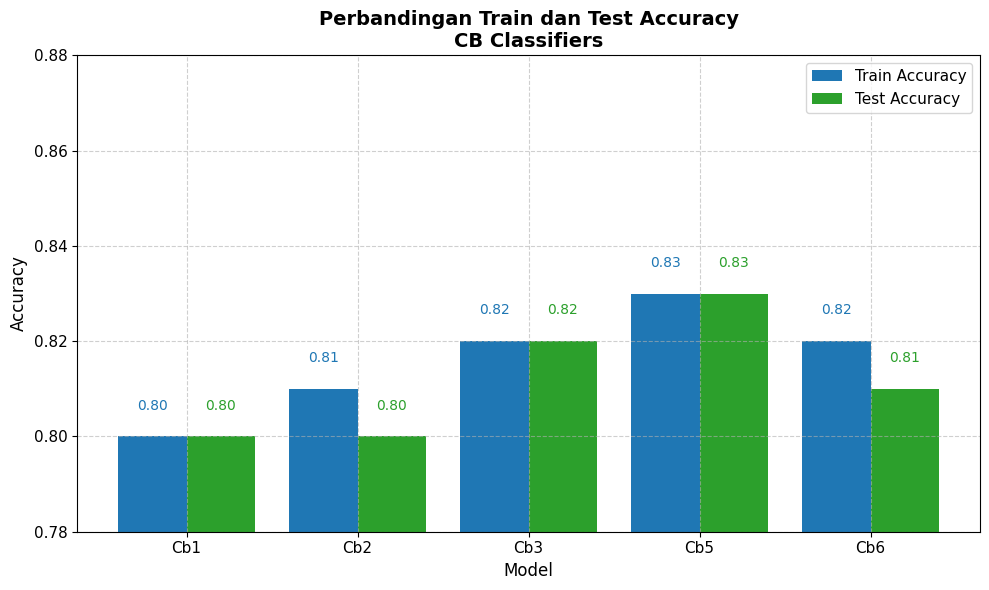

In [ ]:
models = ['Cb1', 'Cb2', 'Cb3', 'Cb4', 'Cb5']
train_accuracies = [0.80, 0.81, 0.83, 0.84, 0.82]
test_accuracies = [0.80, 0.80, 0.82, 0.84, 0.82]

bar_width = 0.4
x = np.arange(len(models))
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, train_accuracies, bar_width, label='Train Accuracy', color='#1f77b4')
plt.bar(x + bar_width/2, test_accuracies, bar_width, label='Test Accuracy', color='#2ca02c')


for i, (xt, yt) in enumerate(zip(x, train_accuracies)):
    plt.text(xt - bar_width/2, yt + 0.005, f'{yt:.2f}', ha='center', va='bottom', color='#1f77b4')
for i, (xt, yt) in enumerate(zip(x, test_accuracies)):
    plt.text(xt + bar_width/2, yt + 0.005, f'{yt:.2f}', ha='center', va='bottom', color='#2ca02c')


plt.xticks(x, models, fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Perbandingan Train dan Test Accuracy\nCB Classifiers', fontsize=14, fontweight='bold')
plt.ylim(0.78, 0.88)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

# Ensemble (voting)

In [ ]:
rf1 = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=8,
    min_samples_leaf=6,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42
)

cb3 = CatBoostClassifier(
    iterations=700,
    depth=12,
    learning_rate=0.02,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=3,
    border_count=128
)

ensemble_model1 = VotingClassifier(
    estimators=[('rf', rf1), ('cb', cb3)],
    voting='soft'
)

ensemble_model1.fit(X_train_smote, y_train_smote)

ensemble_predictions_train = ensemble_model1.predict(X_train_smote)
ensemble_predictions_test = ensemble_model1.predict(X_test_resampled)

accuracy_train = accuracy_score(y_train_smote, ensemble_predictions_train)
print(f"Ensemble Model Train Accuracy: {accuracy_train:.2f}")
print("Ensemble Model Train Classification Report:")
print(classification_report(y_train_smote, ensemble_predictions_train))
print("Ensemble Model Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, ensemble_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, ensemble_predictions_test)
print(f"Ensemble Model Test Accuracy: {accuracy_test:.2f}")
print("Ensemble Model Test Classification Report:")
print(classification_report(y_test_resampled, ensemble_predictions_test))
print("Ensemble Model Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, ensemble_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

Ensemble Model Train Accuracy: 0.84
Ensemble Model Train Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83    227126
           1       0.81      0.90      0.85    227126

    accuracy                           0.84    454252
   macro avg       0.85      0.84      0.84    454252
weighted avg       0.85      0.84      0.84    454252

Ensemble Model Train Confusion Matrix:
[[178643  48483]
 [ 23409 203717]]
Ensemble Model Test Accuracy: 0.84
Ensemble Model Test Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      5078
           1       0.80      0.90      0.85      5078

    accuracy                           0.84     10156
   macro avg       0.84      0.84      0.84     10156
weighted avg       0.84      0.84      0.84     10156

Ensemble Model Test Confusion Matrix:
[[3975 1103]
 [ 527 4551]]
Selisih Akurasi: 0.00


# feature importance

In [ ]:
rf1 = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=8,
    min_samples_leaf=6,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42
)

cb3 = CatBoostClassifier(
    iterations=700,
    depth=12,
    learning_rate=0.02,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=3,
    border_count=128
)

ensemble_model1 = VotingClassifier(
    estimators=[('rf', rf1), ('cb', cb3)],
    voting='soft'
)
ensemble_model1.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")

accuracy_test = ensemble_model1.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model (ensemble_model1) di Data Tes: {accuracy_test:.4f}\n")


print("Menghitung Permutation Importance pada data tes untuk model Ensemble...")
result = permutation_importance(
    ensemble_model1,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
print("Perhitungan selesai.\n")


sorted_importances_idx = result.importances_mean.argsort()[::-1]

importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})

importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

pd.options.display.float_format = '{:,.4f}'.format
print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (MODEL ENSEMBLE)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")
print(importance_summary.to_string())
print("="*80)

Model selesai dilatih.
Akurasi Awal Model (ensemble_model1) di Data Tes: 0.8394

Menghitung Permutation Importance pada data tes untuk model Ensemble...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (MODEL ENSEMBLE)
                  Akurasi Awal Model: 0.8394
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.1836   0.0035                 0.6558
1   General_Health             0.1404   0.0037                 0.6990
2              BMI             0.0758   0.0028                 0.7636
3              Sex             0.0534   0.0012                 0.7860
4         Diabetes             0.0432   0.0014                 0.7962
5  Smoking_History             0.0385   0.0021                 0.8009
6        Arthritis             0.0367   0.0015                 0.8027
7         Exercise             0.0344   0.0020                 0.8050


In [ ]:
rf2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

cb4 = CatBoostClassifier(
    iterations=900,
    depth=15,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=3,
    border_count=128,
    bagging_temperature=0.5
)

# Buat ensemble model dengan soft voting
ensemble_model2 = VotingClassifier(
    estimators=[('rf', rf2), ('cb', cb5)],
    voting='soft'
)

# Fit model ensemble pada data train
ensemble_model2.fit(X_train_smote, y_train_smote)

# Prediksi pada data train dan test
ensemble_predictions_train = ensemble_model2.predict(X_train_smote)
ensemble_predictions_test = ensemble_model2.predict(X_test_resampled)

# Evaluasi akurasi
accuracy_train = accuracy_score(y_train_smote, ensemble_predictions_train)
print(f"Ensemble Model Train Accuracy: {accuracy_train:.2f}")
print("Ensemble Model Train Classification Report:")
print(classification_report(y_train_smote, ensemble_predictions_train))
print("Ensemble Model Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, ensemble_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, ensemble_predictions_test)
print(f"Ensemble Model Test Accuracy: {accuracy_test:.2f}")
print("Ensemble Model Test Classification Report:")
print(classification_report(y_test_resampled, ensemble_predictions_test))
print("Ensemble Model Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, ensemble_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

Ensemble Model Train Accuracy: 0.91
Ensemble Model Train Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91    227126
           1       0.89      0.95      0.92    227126

    accuracy                           0.91    454252
   macro avg       0.92      0.91      0.91    454252
weighted avg       0.92      0.91      0.91    454252

Ensemble Model Train Confusion Matrix:
[[200242  26884]
 [ 12313 214813]]
Ensemble Model Test Accuracy: 0.91
Ensemble Model Test Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      5078
           1       0.89      0.94      0.91      5078

    accuracy                           0.91     10156
   macro avg       0.91      0.91      0.91     10156
weighted avg       0.91      0.91      0.91     10156

Ensemble Model Test Confusion Matrix:
[[4464  614]
 [ 280 4798]]
Selisih Akurasi: 0.00


# feature importance

Melatih model Ensemble (ensemble_model2)...
Model selesai dilatih.
Akurasi Awal Model (ensemble_model2) di Data Tes: 0.9128

Menghitung Permutation Importance pada data tes untuk model Ensemble (ensemble_model2)...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (MODEL ENSEMBLE 2)
                  Akurasi Awal Model: 0.9128
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.2671   0.0041                 0.6456
1   General_Health             0.2165   0.0021                 0.6962
2              BMI             0.2094   0.0027                 0.7034
3              Sex             0.1180   0.0025                 0.7948
4  Smoking_History             0.1042   0.0027                 0.8086
5        Arthritis             0.1024   0.0027                 0.8103
6         Diabetes             0.1000   0.0015                 0.8128
7         Exercise     

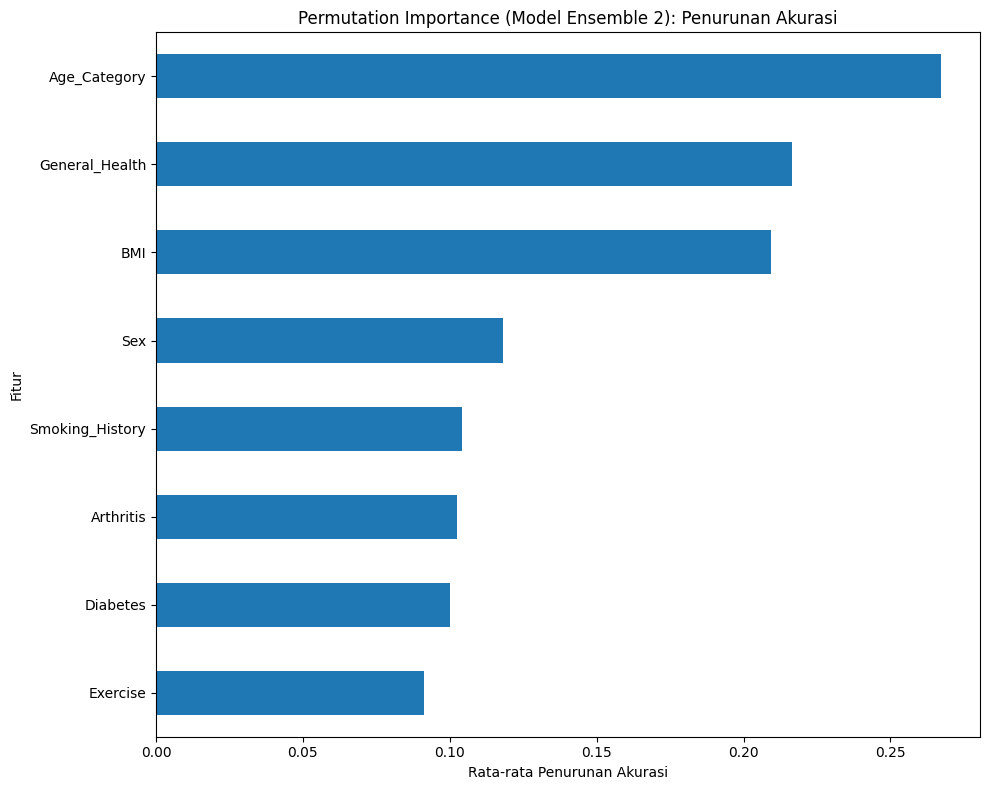

In [ ]:
# --- Bagian 2: Melatih Model Ensemble Anda (ensemble_model2) ---
print("Melatih model Ensemble (ensemble_model2)...")

# Mendefinisikan model-model individual
rf2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

cb4 = CatBoostClassifier(
    iterations=900,
    depth=15,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=3,
    border_count=128,
    bagging_temperature=0.5
)

# Mendefinisikan dan melatih model ensemble
# Catatan: Menggunakan 'cb4' sesuai definisi di atas.
ensemble_model2 = VotingClassifier(
    estimators=[('rf', rf2), ('cb', cb4)],
    voting='soft'
)
ensemble_model2.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")

# Menghitung akurasi awal pada data tes sebagai baseline
accuracy_test = ensemble_model2.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model (ensemble_model2) di Data Tes: {accuracy_test:.4f}\n")


# --- Bagian 3: Menghitung Permutation Importance ---
print("Menghitung Permutation Importance pada data tes untuk model Ensemble (ensemble_model2)...")
result = permutation_importance(
    ensemble_model2,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1, # Gunakan semua core CPU
    scoring='accuracy'
)
print("Perhitungan selesai.\n")


# --- Bagian 4: Mengolah dan Menampilkan Hasil ---
# Mengurutkan fitur berdasarkan tingkat kepentingannya
sorted_importances_idx = result.importances_mean.argsort()[::-1]

# Membuat DataFrame ringkasan
importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})

# Menambahkan kolom prediksi akurasi baru jika fitur dihilangkan
importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

# Menampilkan hasil akhir dalam format tabel yang rapi
pd.options.display.float_format = '{:,.4f}'.format
print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (MODEL ENSEMBLE 2)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")
print(importance_summary.to_string())
print("="*80)

# Membuat visualisasi hasil
fig, ax = plt.subplots(figsize=(10, 8))
importance_summary.plot.barh(x='Fitur', y='Penurunan Akurasi', ax=ax, legend=False)
ax.set_title("Permutation Importance (Model Ensemble 2): Penurunan Akurasi")
ax.set_xlabel("Rata-rata Penurunan Akurasi")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

In [ ]:
# Definisikan model Random Forest dan CatBoost
rf3 = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=3,
    max_features='log2',
    class_weight='balanced',
    random_state=42
)

cb5 = CatBoostClassifier(
    iterations=1000,
    depth=15,
    learning_rate=0.005,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=5,
    border_count=256,
    bagging_temperature=0.7
)

ensemble_model3 = VotingClassifier(
    estimators=[('rf', rf3), ('cb', cb6)],
    voting='soft'
)

ensemble_model3.fit(X_train_smote, y_train_smote)

ensemble_predictions_train = ensemble_model3.predict(X_train_smote)
ensemble_predictions_test = ensemble_model3.predict(X_test_resampled)

accuracy_train = accuracy_score(y_train_smote, ensemble_predictions_train)
print(f"Ensemble Model Train Accuracy: {accuracy_train:.2f}")
print("Ensemble Model Train Classification Report:")
print(classification_report(y_train_smote, ensemble_predictions_train))
print("Ensemble Model Train Confusion Matrix:")
print(confusion_matrix(y_train_smote, ensemble_predictions_train))

accuracy_test = accuracy_score(y_test_resampled, ensemble_predictions_test)
print(f"Ensemble Model Test Accuracy: {accuracy_test:.2f}")
print("Ensemble Model Test Classification Report:")
print(classification_report(y_test_resampled, ensemble_predictions_test))
print("Ensemble Model Test Confusion Matrix:")
print(confusion_matrix(y_test_resampled, ensemble_predictions_test))

print(f"Selisih Akurasi: {abs(accuracy_train - accuracy_test):.2f}")

Ensemble Model Train Accuracy: 0.88
Ensemble Model Train Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88    227126
           1       0.85      0.93      0.89    227126

    accuracy                           0.88    454252
   macro avg       0.89      0.88      0.88    454252
weighted avg       0.89      0.88      0.88    454252

Ensemble Model Train Confusion Matrix:
[[190823  36303]
 [ 16599 210527]]
Ensemble Model Test Accuracy: 0.88
Ensemble Model Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      5078
           1       0.85      0.93      0.89      5078

    accuracy                           0.88     10156
   macro avg       0.89      0.88      0.88     10156
weighted avg       0.89      0.88      0.88     10156

Ensemble Model Test Confusion Matrix:
[[4265  813]
 [ 379 4699]]
Selisih Akurasi: 0.00


# feature importance

In [ ]:
print("Melatih model Ensemble (ensemble_model3)...")

# Mendefinisikan model-model individual
rf3 = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=3,
    max_features='log2',
    class_weight='balanced',
    random_state=42
)

cb5 = CatBoostClassifier(
    iterations=1000,
    depth=15,
    learning_rate=0.005,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced',
    l2_leaf_reg=5,
    border_count=256,
    bagging_temperature=0.7
)

# Mendefinisikan dan melatih model ensemble
# Koreksi: Menggunakan cb5 yang sudah didefinisikan
ensemble_model3 = VotingClassifier(
    estimators=[('rf', rf3), ('cb', cb5)],
    voting='soft'
)
ensemble_model3.fit(X_train_smote, y_train_smote)
print("Model selesai dilatih.")

# Menghitung akurasi awal pada data tes sebagai baseline
accuracy_test = ensemble_model3.score(X_test_resampled, y_test_resampled)
print(f"Akurasi Awal Model (ensemble_model3) di Data Tes: {accuracy_test:.4f}\n")


# --- Bagian 3: Menghitung Permutation Importance ---
print("Menghitung Permutation Importance pada data tes untuk model Ensemble (ensemble_model3)...")
result = permutation_importance(
    ensemble_model3,
    X_test_resampled,
    y_test_resampled,
    n_repeats=10,
    random_state=42,
    n_jobs=-1, # Gunakan semua core CPU
    scoring='accuracy'
)
print("Perhitungan selesai.\n")


# --- Bagian 4: Mengolah dan Menampilkan Hasil ---
# Mengurutkan fitur berdasarkan tingkat kepentingannya
sorted_importances_idx = result.importances_mean.argsort()[::-1]

# Membuat DataFrame ringkasan
importance_summary = pd.DataFrame({
    'Fitur': X_test_resampled.columns[sorted_importances_idx],
    'Penurunan Akurasi': result.importances_mean[sorted_importances_idx],
    'Std Dev': result.importances_std[sorted_importances_idx]
})

# Menambahkan kolom prediksi akurasi baru jika fitur dihilangkan
importance_summary['Prediksi Akurasi Baru'] = accuracy_test - importance_summary['Penurunan Akurasi']

# Menampilkan hasil akhir dalam format tabel yang rapi
pd.options.display.float_format = '{:,.4f}'.format
print("="*80)
print("                  HASIL PERMUTATION IMPORTANCE (MODEL ENSEMBLE 3)")
print(f"                  Akurasi Awal Model: {accuracy_test:.4f}")
print("="*80)
print("Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).")
print(importance_summary.to_string())
print("="*80)


Melatih model Ensemble (ensemble_model3)...
Model selesai dilatih.
Akurasi Awal Model (ensemble_model3) di Data Tes: 0.8829

Menghitung Permutation Importance pada data tes untuk model Ensemble (ensemble_model3)...
Perhitungan selesai.

                  HASIL PERMUTATION IMPORTANCE (MODEL ENSEMBLE 3)
                  Akurasi Awal Model: 0.8829
Menunjukkan estimasi akurasi jika sebuah fitur dihilangkan (diacak).
             Fitur  Penurunan Akurasi  Std Dev  Prediksi Akurasi Baru
0     Age_Category             0.2333   0.0036                 0.6497
1   General_Health             0.1876   0.0029                 0.6953
2              BMI             0.1481   0.0041                 0.7348
3              Sex             0.0921   0.0020                 0.7909
4  Smoking_History             0.0750   0.0018                 0.8080
5         Diabetes             0.0744   0.0019                 0.8086
6        Arthritis             0.0723   0.0019                 0.8106
7         Exercise     

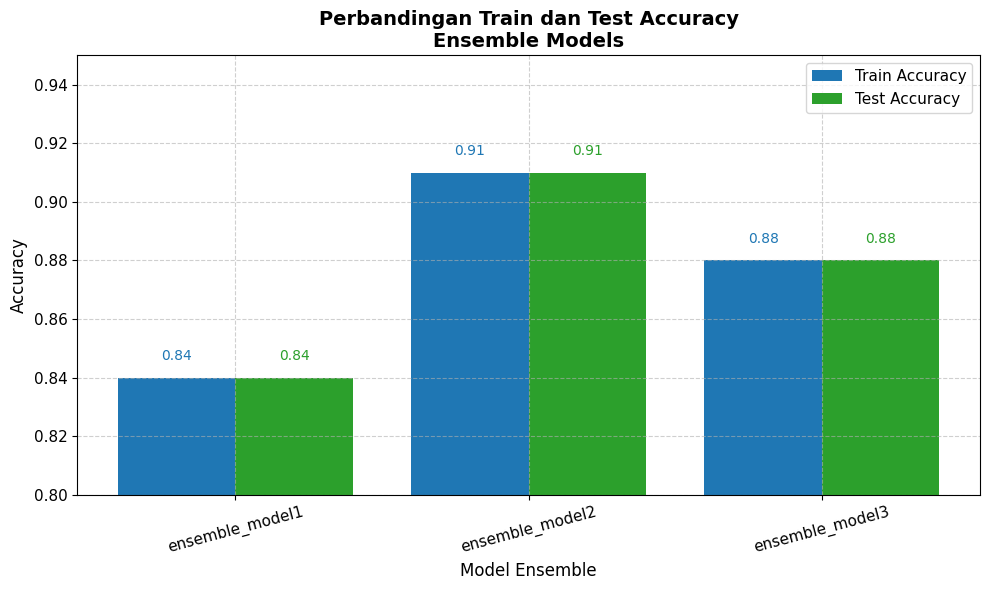

In [ ]:
# Data akurasi untuk masing-masing model ensemble
models = ['ensemble_model1', 'ensemble_model2', 'ensemble_model3']
train_accuracies = [0.84, 0.91, 0.88]
test_accuracies = [0.84, 0.91, 0.88]

# Konstanta warna
TRAIN_COLOR = '#1f77b4'
TEST_COLOR = '#2ca02c'

# Buat histogram
bar_width = 0.4
x = np.arange(len(models))
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, train_accuracies, bar_width, label='Train Accuracy', color=TRAIN_COLOR)
plt.bar(x + bar_width/2, test_accuracies, bar_width, label='Test Accuracy', color=TEST_COLOR)

# Tambahkan label nilai di atas tiap batang
for i, (xt, yt) in enumerate(zip(x, train_accuracies)):
    plt.text(xt - bar_width/2, yt + 0.005, f'{yt:.2f}', ha='center', va='bottom', color=TRAIN_COLOR)
for i, (xt, yt) in enumerate(zip(x, test_accuracies)):
    plt.text(xt + bar_width/2, yt + 0.005, f'{yt:.2f}', ha='center', va='bottom', color=TEST_COLOR)

# Atur ticks, label, title, dan grid
plt.xticks(x, models, fontsize=11, rotation=15)
plt.yticks(fontsize=11)
plt.xlabel('Model Ensemble', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Perbandingan Train dan Test Accuracy\nEnsemble Models', fontsize=14, fontweight='bold')
plt.ylim(0.80, 0.95)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

# Tampilkan grafik
plt.show()

#Visualisasi Grafik Accuracy Semua Model

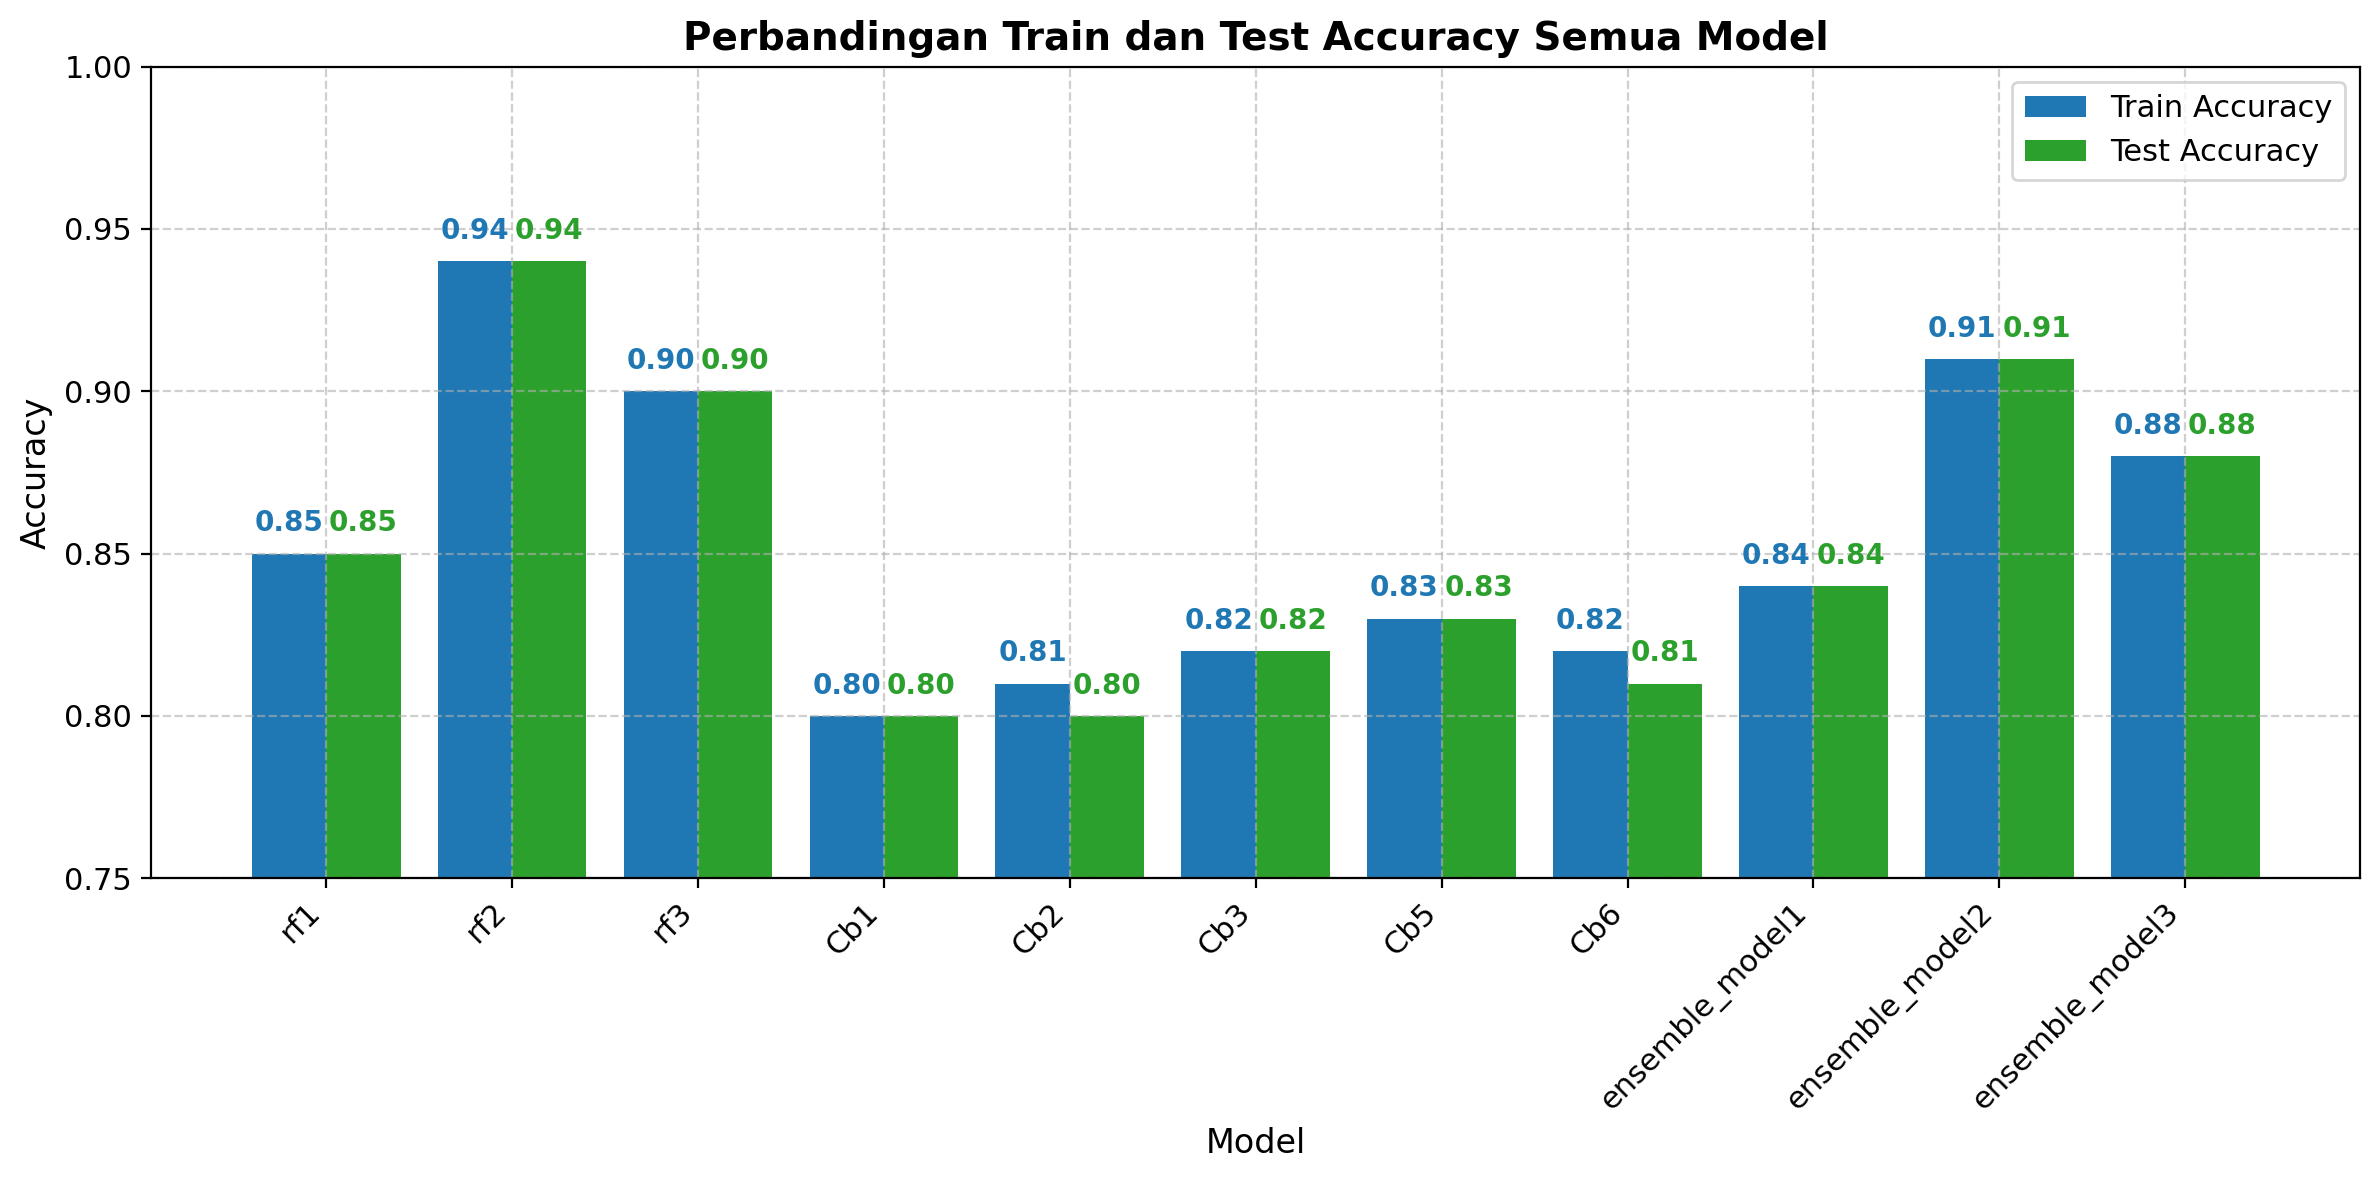

In [ ]:
models = ['rf1', 'rf2', 'rf3', 'Cb1', 'Cb2', 'Cb3', 'Cb5', 'Cb6', 'ensemble_model1', 'ensemble_model2', 'ensemble_model3']
train_accuracies = [0.85, 0.94, 0.90, 0.80, 0.81, 0.82, 0.83, 0.82, 0.84, 0.91, 0.88]
test_accuracies = [0.85, 0.94, 0.90, 0.80, 0.80, 0.82, 0.83, 0.81, 0.84, 0.91, 0.88]

plt.figure(figsize=(12, 6), dpi=200)


bar_width = 0.4
x = np.arange(len(models))
plt.bar(x - bar_width/2, train_accuracies, bar_width, label='Train Accuracy', color='#1f77b4')
plt.bar(x + bar_width/2, test_accuracies, bar_width, label='Test Accuracy', color='#2ca02c')


for i, (xt, yt) in enumerate(zip(x, train_accuracies)):
    plt.text(xt - bar_width/2, yt + 0.005, f'{yt:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1f77b4')
for i, (xt, yt) in enumerate(zip(x, test_accuracies)):
    plt.text(xt + bar_width/2, yt + 0.005, f'{yt:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2ca02c')


plt.xticks(x, models, rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Perbandingan Train dan Test Accuracy Semua Model', fontsize=14, fontweight='bold')
plt.ylim(0.75, 1.00)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()
